# Градиентный бустинг: от идеи до промышленных реализаций

В этом ноутбуке мы пройдём по основным блокам градиентного бустинга и поймём, почему они устроены именно так. После этого посмотрим на три промышленных реализации, которые сегодня считаются стандартом: **XGBoost**, **LightGBM** и **CatBoost**.

Структура:

1. Базовый градиентный бустинг и интуиция за каждым его блоком.
2. Почему сдвиги считаются через производные функции потерь.
3. Почему базовая модель приближает сдвиги именно по MSE.
4. Что нам мешает обучить одно глубокое дерево.
5. Перенос идей из оптимизации (метод Нестерова) на бустинг.
6. Проблема экстраполяции.
7. Сложность обучения.
8. XGBoost: вторые производные, регуляризация, поиск разбиений.
9. LightGBM: GOSS, EFB, leaf-wise рост.
10. CatBoost: oblivious deсision trees.


## Подготовка окружения

In [1]:
import numpy as np
from matplotlib.patches import Arc
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle, Rectangle
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'legend.frameon': False,
})

PALETTE = {
    'blue':    '#2E86AB',
    'red':     '#E63946',
    'green':   '#06A77D',
    'orange':  '#F18F01',
    'purple':  '#7E57C2',
    'gray':    '#6C757D',
    'dark':    '#1D3557',
    'light':   '#A8DADC',
}
print('Окружение готово.')

Окружение готово.


## 0. Основные концепции простыми словами

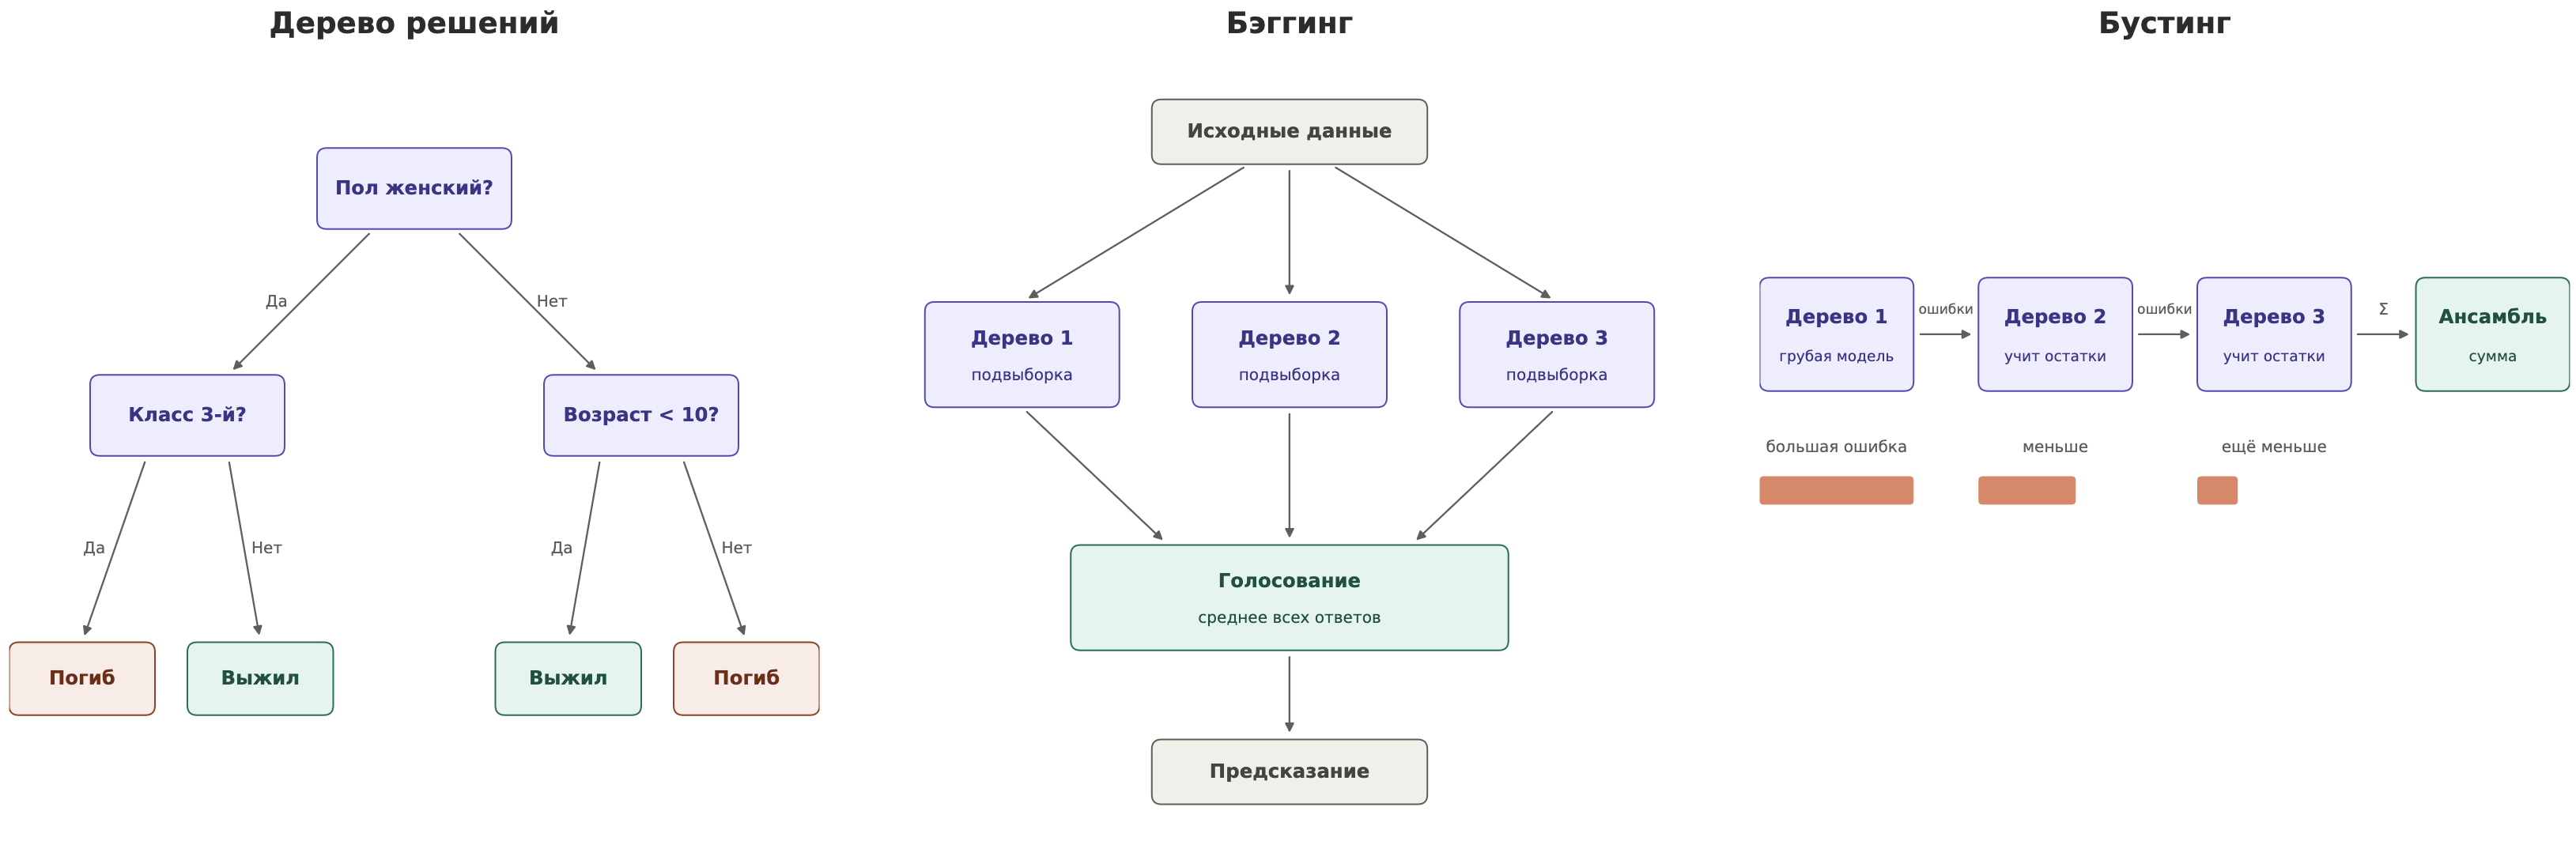

Дерево решений работает как игра в «да-нет»: задаёт вопросы по очереди, пока не выдаст ответ. Просто и понятно, но легко заучивает примеры наизусть и плохо работает на новых данных.


Бэггинг решает эту проблему хитро. Берём много деревьев, каждое учим на своём кусочке данных, а потом голосуем. Как консилиум врачей: один доктор может ошибиться, а десять одновременно вряд ли.


Бустинг идёт другим путём. Деревья строятся по очереди, и каждое следующее исправляет ошибки предыдущего. Получается цепочка учеников, где каждый дотягивает то, что не вытянул сосед, а в сумме они работают лучше любого одиночки.

## 1. Градиентный бустинг: научное напоминание

Будем искать алгоритм, оптимизирующий некоторую дифференцируемую функцию потерь $L(y, z)$, в виде взвешенной суммы базовых алгоритмов:

$$
a_N(x) = \sum_{n=0}^{N} \gamma_n b_n(x), \tag{1}
$$

где $a_N(x)$ – итоговая композиция из $N+1$ алгоритма, $b_n(x)$ – базовые алгоритмы (обычно неглубокие решающие деревья), $\gamma_n \in \mathbb{R}$ – их веса.

Если на пальцах: суммируем прогнозы нескольких слабых алгоритмов с весами и получаем одну сильную модель.

Веса $\gamma_n$ часто полагают равными единице (поскольку в деревьях всё равно потом тщательно подбираются прогнозы в листьях), но в общем виде они есть.

Идея бустинга в том, чтобы строить базовые алгоритмы последовательно, и каждый новый учитывал ошибки уже построенной композиции:

$$
\sum_{i=1}^{\ell} L\bigl(y_i,\; a_{N-1}(x_i) + \gamma_N b_N(x_i)\bigr) \to \min_{b_N, \gamma_N}, \tag{2}
$$

где $\ell$ – размер обучающей выборки, $(x_i, y_i)$ – обучающие пары «объект, ответ», а минимизация ведётся по очередному базовому алгоритму $b_N$ и его весу $\gamma_N$ при уже зафиксированной композиции $a_{N-1}$.

**Суть**: на каждом шаге ищем такие $b_N$ и $\gamma_N$, чтобы суммарная ошибка композиции стала меньше.

После простой инициализации (для регрессии например $b_0(x) = \frac{1}{\ell}\sum y_i$) все последующие базовые алгоритмы стараются приблизить **антиградиент** функционала ошибки, посчитанный в точках $z = a_{N-1}(x_i)$:

$$
s_i = -\left.\frac{\partial L(y_i, z)}{\partial z}\right|_{z=a_{N-1}(x_i)}, \tag{3}
$$

где $s_i$ – значение антиградиента на $i$-м объекте: направление, в котором нужно сдвинуть прогноз $a_{N-1}(x_i)$, чтобы $L$ на нём убывала быстрее всего.

**Суть**: для каждого объекта считаем, в какую сторону «недотянул» текущий прогноз.

При этом сам антиградиент приближается с точки зрения **квадратичной** функции потерь:

$$
b_N(x) = \arg\min_{b \in \mathcal{A}} \sum_{i=1}^{\ell} \bigl(b(x_i) - s_i\bigr)^2, \tag{4}
$$

где $\mathcal{A}$ – семейство базовых алгоритмов (например, деревья ограниченной глубины). Задача обучения $b_N$ при этом всегда регрессионная и всегда с MSE, независимо от исходной задачи и вида $L$.

**Суть**: учим очередное дерево обычной регрессией, а целевые значения для него – антиградиенты.

И уже после этого подбирается коэффициент $\gamma_N$ как обычная одномерная оптимизация:

$$
\gamma_N = \arg\min_{\gamma \in \mathbb{R}} \sum_{i=1}^{\ell} L\bigl(y_i,\; a_{N-1}(x_i) + \gamma b_N(x_i)\bigr). \tag{5}
$$

Минимум здесь берётся по исходному $L$, и именно поэтому квадратичная аппроксимация на предыдущем шаге не мешает корректно учиться под любую дифференцируемую функцию потерь.

**Суть**: подбираем длину шага в найденном направлении, уже по настоящей $L$, а не по её квадратичной аппроксимации.

Дальше мы по очереди обсудим каждый из этих блоков: почему они устроены именно так, и что было бы, если бы мы сделали по-другому.


### Демонстрация: как бустинг постепенно строит сложную функцию

Сначала визуализируем сам процесс. Возьмём простую задачу регрессии и посмотрим, как композиция деревьев глубины 3 шаг за шагом приближается к истинной функции. Каждое отдельное дерево короткое и слабое, но их сумма даёт гладкую и точную модель.

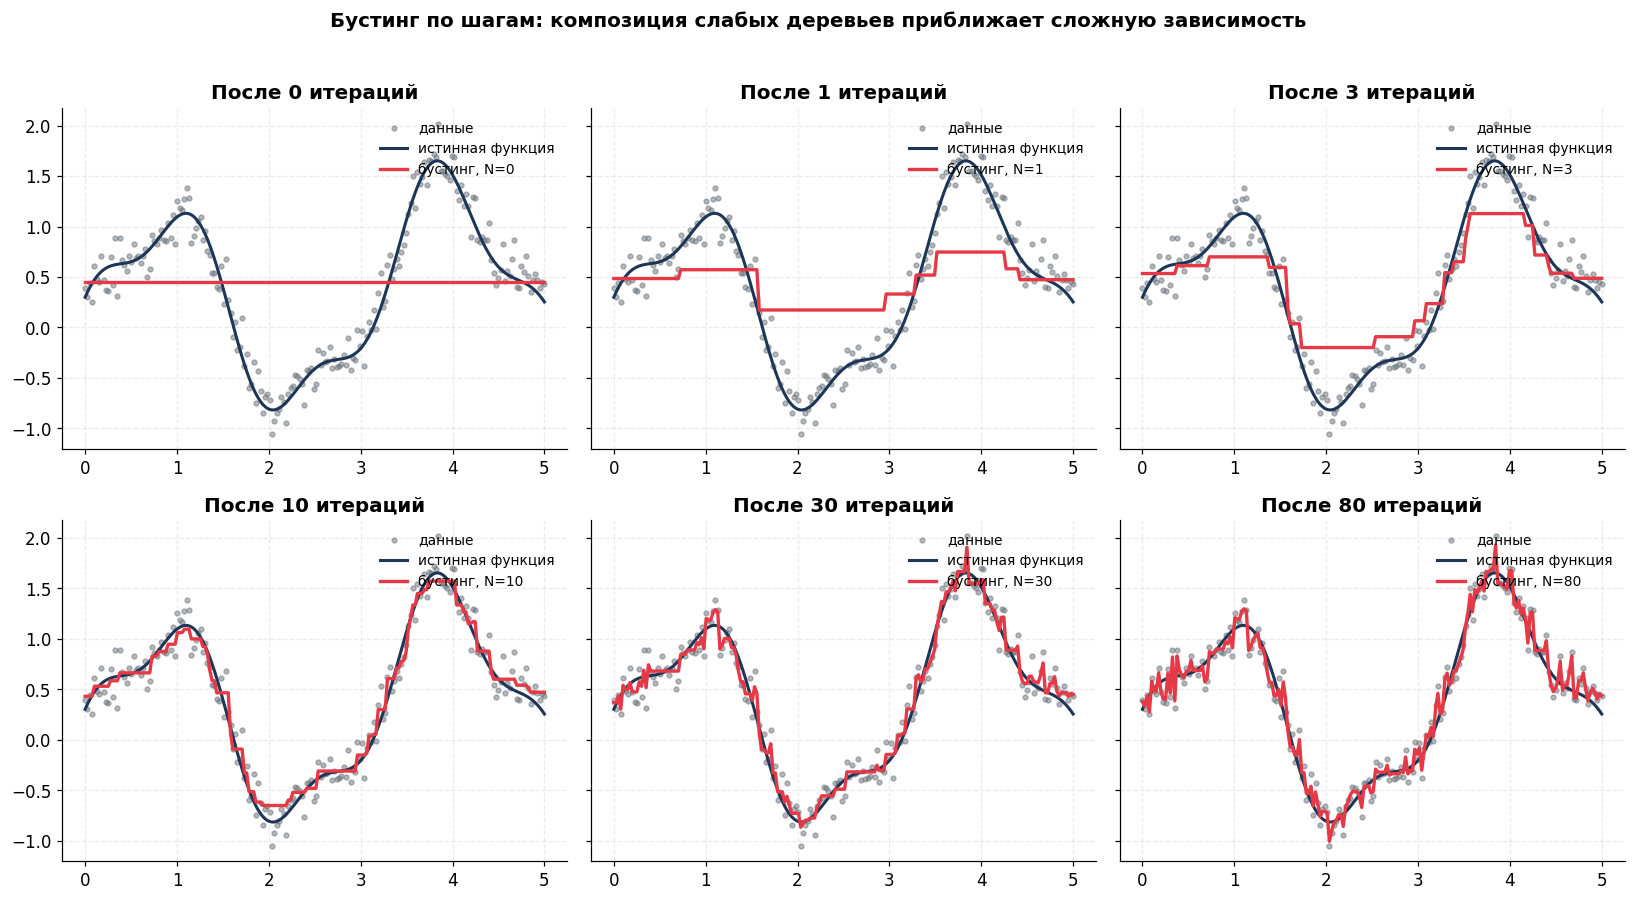

In [ ]:
def true_func(x):
    return np.sin(2 * x) + 0.3 * np.cos(5 * x) + 0.1 * x

X = np.linspace(0, 5, 200).reshape(-1, 1)
y_true = true_func(X.ravel())
y = y_true + np.random.normal(0, 0.15, size=X.shape[0])

N_TREES = 80      # число базовых алгоритмов N из формулы (1)
LR = 0.3          # фиксированный gamma_n — упрощение формулы (5)

# инициализация: b_0(x) = (1/ell) * sum y_i, то есть стартовая композиция a_0(x).
predictions = np.full_like(y, y.mean(), dtype=float)

stages = {0: predictions.copy()}
trees = []
for n in range(1, N_TREES + 1):
    # === на этой итерации решаем задачу (2): ===
    # min_{b_n, gamma_n} sum L(y_i, a_{n-1}(x_i) + gamma_n * b_n(x_i))
    # на практике — через шаги (3) -> (4) -> (1).

    # формула (3): антиградиент в точках z = a_{n-1}(x_i).
    # Для MSE-лосса s_i = y_i - a_{n-1}(x_i), то есть просто остатки.
    residuals = y - predictions

    # формула (4): b_n = argmin sum (b(x_i) - s_i)^2,
    # учим дерево как обычную MSE-регрессию по антиградиентам.
    tree = DecisionTreeRegressor(max_depth=3)
    tree.fit(X, residuals)

    # формула (1), шаг индукции: a_n(x) = a_{n-1}(x) + gamma_n * b_n(x).
    # gamma_n здесь не оптимизируется (формула (5)), а зафиксирован как LR.
    predictions = predictions + LR * tree.predict(X)

    trees.append(tree)
    if n in (1, 3, 10, 30, 80):
        stages[n] = predictions.copy()


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.ravel()
for ax, (n, pred) in zip(axes, stages.items()):
    ax.scatter(X, y, color=PALETTE['gray'], s=10, alpha=0.5, label='данные')
    ax.plot(X, y_true, color=PALETTE['dark'], lw=2, label='истинная функция')
    ax.plot(X, pred, color=PALETTE['red'], lw=2.2, label=f'бустинг, N={n}')
    ax.set_title(f'После {n} итераций')
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Бустинг по шагам: композиция слабых деревьев приближает сложную зависимость',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## §1.1 Почему градиентный бустинг устроен именно так?

### Зачем сдвиги в бустинге считаются через производные функции потерь?

В бустинге **сдвиг** – это поправка, которую каждая новая модель добавляет к предсказанию предыдущих.

Почему нельзя использовать сдвиги вида $y_i  –  a_{N-1}(x_i)$? Казалось бы, если удастся хорошо приблизить эти отклонения, то будет выполнено $a_{N-1}(x_i) + b_N(x_i) \approx y_i$, чего мы и хотим.

Но мы решаем сложные задачи, в которых данные не идеальны: есть шум, выбросы, и вообще нулевой ошибки на обучении мы и не должны достигать. Через функцию потерь мы определяем, **какие ошибки нам важнее, а какие готовы простить**. Если использовать сдвиги, равные разности правильного ответа и прогноза, мы полностью игнорируем эти приоритеты.

Разберём на примере несимметричной функции потерь, где мы сильнее штрафуем за завышение прогноза:

$$
L(y, z) = \tfrac{1}{2}\bigl(10\,[z \geqslant y] + [z < y]\bigr)(y - z)^2. \tag{6}
$$

где $[z \geqslant y]$ и $[z < y]$ – скобки Айверсона, равные $1$ при выполнении условия и $0$ иначе. Множитель $10$ перед первой скобкой и делает штраф за завышение в 10 раз больше.

**Суть**: за завышение прогноза ($z \geqslant y$) штраф в 10 раз больше, чем за занижение, – поэтому при минимизации модель будет «перестраховываться» и систематически чуть-чуть недотягивать до правильного ответа.


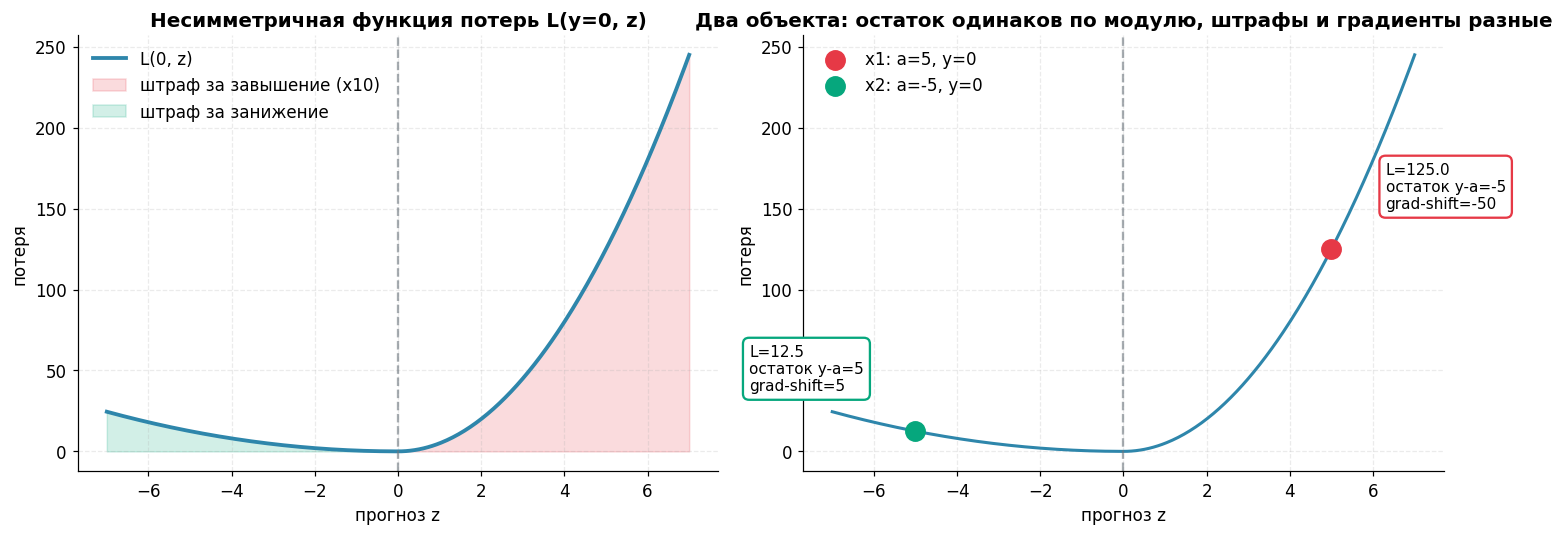

Сравнение для y=0, прогнозы a1=5, a2=-5:
  Простые остатки:  y-a1=  -5, y-a2=   5  (одинаковы по модулю)
  Анти-градиенты:   s1= -50, s2=   5  (на x1 в 10 раз больше)


In [ ]:
def asym_loss(y, z):
    # формула (6): L(y, z) = 0.5 * (10 * [z >= y] + [z < y]) * (y - z)^2
    return 0.5 * np.where(z >= y, 10.0, 1.0) * (y - z) ** 2

def asym_grad(y, z):
    # производная ∂L/∂z для (6). Антиградиент из формулы (3) равен
    # s_i = -∂L/∂z = w * (y - z), где w = 10 при завышении и w = 1 при занижении.
    # Сама функция возвращает именно ∂L/∂z, поэтому ниже s считается как -asym_grad(...).
    return -np.where(z >= y, 10.0, 1.0) * (y - z)

# --- визуализация: к формулам не относится ---
z_grid = np.linspace(-7, 7, 400)
losses = asym_loss(0.0, z_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(z_grid, losses, color=PALETTE['blue'], lw=2.5, label='L(0, z)')
ax.axvline(0, color=PALETTE['gray'], ls='--', alpha=0.6)
ax.fill_between(z_grid, 0, losses, where=(z_grid >= 0),
                color=PALETTE['red'], alpha=0.18, label='штраф за завышение (x10)')
ax.fill_between(z_grid, 0, losses, where=(z_grid < 0),
                color=PALETTE['green'], alpha=0.18, label='штраф за занижение')
ax.set_title('Несимметричная функция потерь L(y=0, z)')
ax.set_xlabel('прогноз z')
ax.set_ylabel('потеря')
ax.legend(loc='upper left')

# два объекта с одинаковым |остатком|=5, но в разные стороны:о
# x1: z=5, y=0 — завышение, антиградиент = 10 * (0-5) = -50
# x2: z=-5, y=0 — занижение, антиградиент = 1 * (0-(-5)) = 5
ax = axes[1]
points = {'x1: a=5, y=0': (5.0, 0.0), 'x2: a=-5, y=0': (-5.0, 0.0)}
colors = [PALETTE['red'], PALETTE['green']]
for (label, (a, y_)), c in zip(points.items(), colors):
    ax.scatter([a], [asym_loss(y_, a)], s=160, color=c, zorder=5, label=label)
    ax.annotate(f'L={asym_loss(y_, a):.1f}\nостаток y-a={y_-a:.0f}\ngrad-shift={-asym_grad(y_, a):.0f}',
                xy=(a, asym_loss(y_, a)),
                xytext=(a + (1.3 if a > 0 else -4), asym_loss(y_, a) + 25),
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=c, lw=1.5))

ax.plot(z_grid, losses, color=PALETTE['blue'], lw=2)
ax.axvline(0, color=PALETTE['gray'], ls='--', alpha=0.6)
ax.set_title('Два объекта: остаток одинаков по модулю, штрафы и градиенты разные')
ax.set_xlabel('прогноз z')
ax.set_ylabel('потеря')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

# наглядное численное сравнение остатков и антиградиентов
print('Сравнение для y=0, прогнозы a1=5, a2=-5:')
print(f'  Простые остатки:  y-a1={0-5:>4}, y-a2={0-(-5):>4}  (одинаковы по модулю)')
print(f'  Анти-градиенты:   s1={-asym_grad(0,5):>4.0f}, s2={-asym_grad(0,-5):>4.0f}'
      '  (на x1 в 10 раз больше)')

Вывод по картинке. Остатки $y_i - a_{N-1}(x_i)$ на обоих объектах одинаковы по модулю и равны $\pm 5$. Это значит, что базовая модель будет одинаково стараться скорректировать оба прогноза. А антиградиенты $s_1 = -50, \; s_2 = 5$ корректно расставляют приоритеты: на $x_1$ штраф в 10 раз больше, потому что мы завысили прогноз, и сдвиг там тоже в 10 раз больше. То, что на $x_1$ корректировка может оказаться слишком сильной, не страшно: это будет исправлено множителем $\gamma_N$ или другими техниками вроде learning rate.

**Суть**: остатки знают только модуль ошибки, а антиградиенты – ещё и её «цену» по функции потерь.

### Случай абсолютной ошибки

Посчитаем сдвиги для $L(y, z) = |y - z|$:

$$
s_i = -\left.\frac{\partial |y_i - z|}{\partial z}\right|_{z=a_{N-1}(x_i)} = \operatorname{sign}\bigl(y_i - a_{N-1}(x_i)\bigr). \tag{7}
$$

где $\operatorname{sign}(\cdot)$ – функция знака: $+1$ при положительном аргументе, $-1$ при отрицательном и $0$ в нуле, а $s_i$ – тот же антиградиент на $i$-м объекте, что и в формуле (3).

И это снова более логично, чем обучаться на $y_i - a_{N-1}(x_i)$. У MAE интересное свойство: уменьшение ошибки с 1000 до 999 и с 1 до 0 одинаково полезно. Поэтому средняя абсолютная ошибка не различает объекты по модулю остатка, важен только знак. Сдвиги по модулю одинаковы и отличаются только знаком, что в точности соответствует свойству MAE.

Для квадратичной ошибки картинка ровно обратная: чем больше отклонение, тем больше штраф и тем сильнее надо корректировать. Поэтому для MSE использовать сдвиги $y_i - a_{N-1}(x_i)$ как раз разумно.

**Суть:** MAE двигает все объекты на одинаковый шаг по знаку ошибки, а MSE двигает пропорционально величине ошибки.


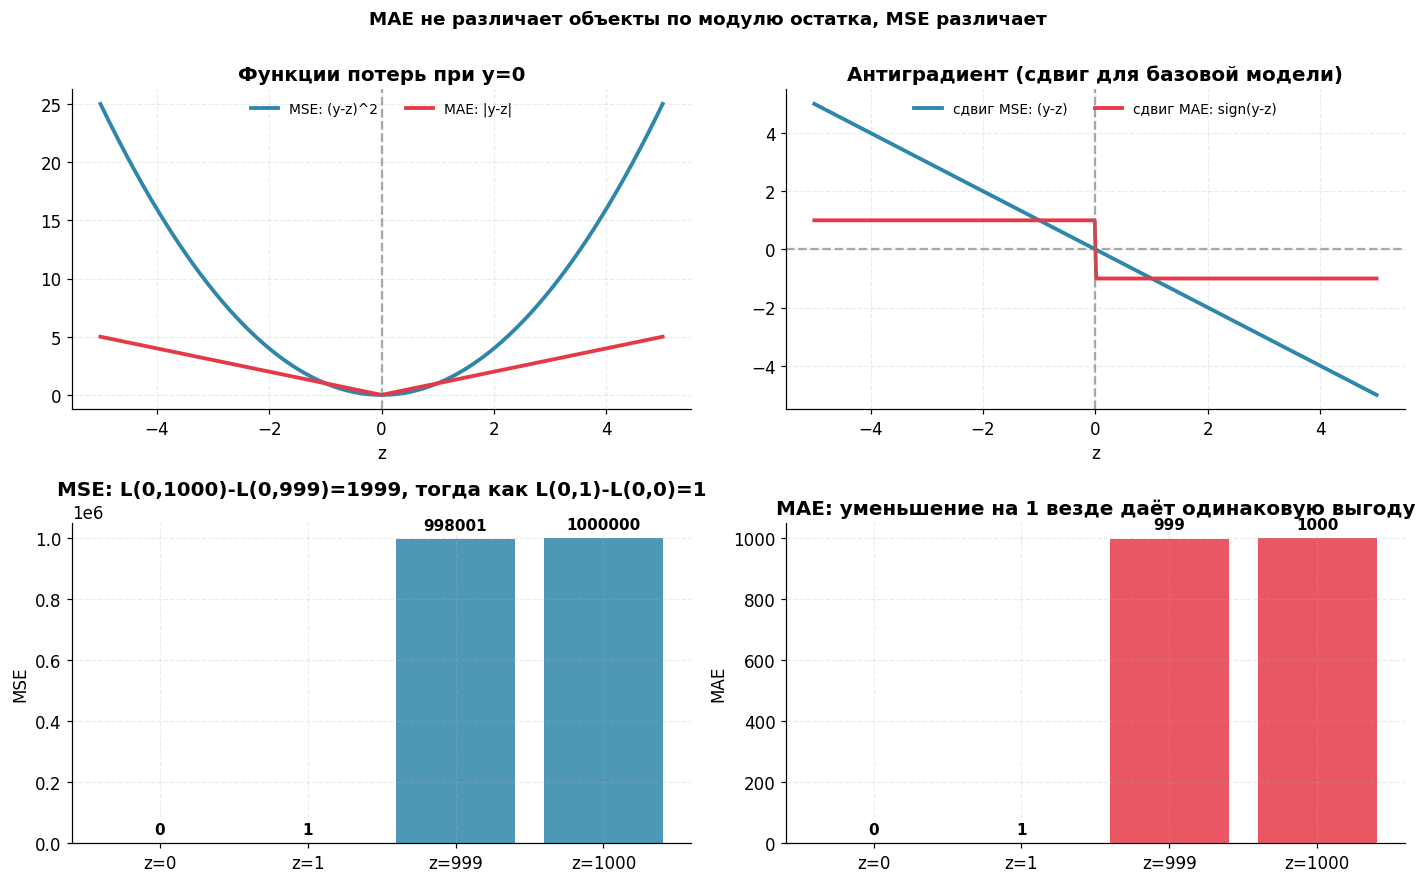

In [ ]:
z_grid = np.linspace(-5, 5, 400)
y_ = 0.0

# функции потерь и их антиградиенты (формула (3), применённая к MSE и MAE):
mse_loss  = (y_ - z_grid) ** 2          # MSE: L(y, z) = (y - z)^2
mae_loss  = np.abs(y_ - z_grid)         # MAE: L(y, z) = |y - z|, левая часть формулы (7)
mse_shift = (y_ - z_grid)               # антиградиент MSE: совпадает с остатком y - z
mae_shift = np.sign(y_ - z_grid)        # антиградиент MAE: sign(y - z), правая часть (7)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# сами функции потерь: парабола MSE и V-образная MAE
ax = axes[0, 0]
ax.plot(z_grid, mse_loss, color=PALETTE['blue'], lw=2.5, label='MSE: (y-z)^2')
ax.plot(z_grid, mae_loss, color=PALETTE['red'], lw=2.5, label='MAE: |y-z|')
ax.axvline(0, color=PALETTE['gray'], ls='--', alpha=0.6)
ax.set_title('Функции потерь при y=0')
ax.set_xlabel('z')
# легенда вынесена в верх по центру: при z≈0 обе кривые на дне, место свободно
ax.legend(loc='upper center', ncol=2, fontsize=9, framealpha=0.9)

# антиградиенты: те самые s_i, на которые учится следующее дерево
ax = axes[0, 1]
ax.plot(z_grid, mse_shift, color=PALETTE['blue'], lw=2.5, label='сдвиг MSE: (y-z)')
ax.plot(z_grid, mae_shift, color=PALETTE['red'], lw=2.5, label='сдвиг MAE: sign(y-z)')
ax.axhline(0, color=PALETTE['gray'], ls='--', alpha=0.6)
ax.axvline(0, color=PALETTE['gray'], ls='--', alpha=0.6)
ax.set_title('Антиградиент (сдвиг для базовой модели)')
ax.set_xlabel('z')
ax.legend(loc='upper center', ncol=2, fontsize=9, framealpha=0.9)

# MSE: разница потерь между близкими по сдвигу точками отличается на порядки
ax = axes[1, 0]
errs = np.array([0, 1, 999, 1000])
mse_vals = errs ** 2
ax.bar([f'z={e}' for e in errs], mse_vals, color=PALETTE['blue'], alpha=0.85)
for i, v in enumerate(mse_vals):
    ax.text(i, v + 30000, f'{v}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('MSE: L(0,1000)-L(0,999)=1999, тогда как L(0,1)-L(0,0)=1')
ax.set_ylabel('MSE')

# MAE: уменьшение ошибки на 1 даёт одинаковую выгоду в любой точке
ax = axes[1, 1]
mae_vals = errs
ax.bar([f'z={e}' for e in errs], mae_vals, color=PALETTE['red'], alpha=0.85)
for i, v in enumerate(mae_vals):
    ax.text(i, v + 30, f'{v}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('MAE: уменьшение на 1 везде даёт одинаковую выгоду')
ax.set_ylabel('MAE')

plt.suptitle('MAE не различает объекты по модулю остатка, MSE различает',
             fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

### Перенос на классификацию

Если у нас два класса $\mathbb{Y} = \{-1, +1\}$, и сама композиция возвращает прогноз тоже из $\mathbb{Y}$, то отклонения $|y_i - a_{N-1}(x_i)|$ принимают значения только из $\{0, 2\}$. На правильно классифицированных объектах сдвиги нулевые, и никакая дальнейшая работа над ними не ведётся. А это плохо: в классификации мы обычно хотим **максимизировать отступ**, а не остановиться сразу после первого правильного предсказания.

Поэтому договариваемся: $a_N(x)$ возвращает вещественные числа, и интерпретируем их как **логиты**, то есть логарифм отношения вероятностей:

$$
a_N(x) = \log \frac{p(y=+1 \mid x)}{1 - p(y=+1 \mid x)}, \qquad p(y=+1 \mid x) = \sigma\bigl(a_N(x)\bigr) = \frac{1}{1 + \exp(-a_N(x))}. \tag{8}
$$

где $p(y=+1 \mid x)$ – вероятность положительного класса для объекта $x$, а $\sigma(\cdot)$ – сигмоида, переводящая вещественный логит в вероятность из интервала $(0, 1)$.

Та же идея, что мы использовали в линейных классификаторах. С таким подходом обучаться на $y_i - a_{N-1}(x_i)$ становится совсем странно: мы бы стали уменьшать отступ там, где он большой положительный, то есть запрещали бы модели быть уверенной в правильном ответе.

**Суть:** в классификации $a_N(x)$ выдаёт не метку класса, а логит, чтобы модель могла продолжать наращивать уверенность в правильном ответе, а не останавливалась сразу после первого верного прогноза.

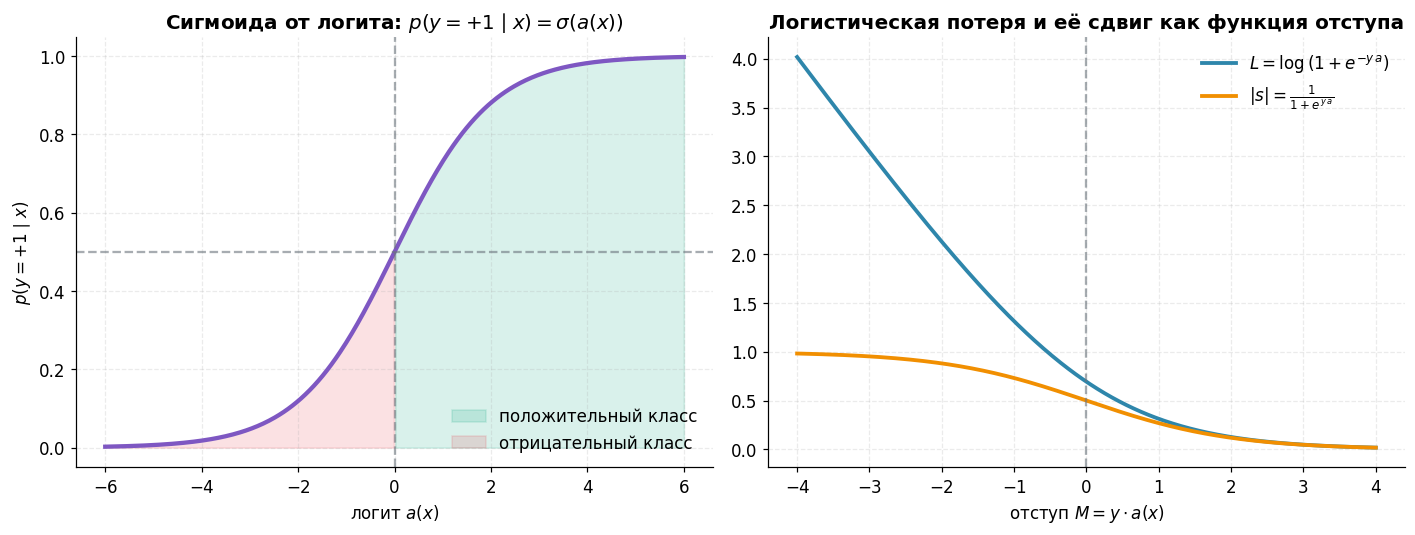

Чем больше отступ, тем меньше сдвиг по модулю.
Это и есть то поведение, которого мы хотим от классификатора.


In [ ]:
logits = np.linspace(-6, 6, 400)
# формула (8): p(y=+1 | x) = σ(a(x)) = 1 / (1 + exp(-a(x)))
probs = 1 / (1 + np.exp(-logits))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# сигмоида: визуализация формулы (8)
ax = axes[0]
ax.plot(logits, probs, color=PALETTE['purple'], lw=2.8)
ax.axhline(0.5, color=PALETTE['gray'], ls='--', alpha=0.6)
ax.axvline(0, color=PALETTE['gray'], ls='--', alpha=0.6)
ax.fill_between(logits, 0, probs, where=(logits > 0), color=PALETTE['green'], alpha=0.15,
                label='положительный класс')
ax.fill_between(logits, 0, probs, where=(logits < 0), color=PALETTE['red'], alpha=0.15,
                label='отрицательный класс')
ax.set_title(r'Сигмоида от логита: $p(y=+1 \mid x) = \sigma(a(x))$')
ax.set_xlabel(r'логит $a(x)$')
ax.set_ylabel(r'$p(y=+1 \mid x)$')
ax.legend(loc='lower right')

# логистическая потеря и её антиградиент как функции отступа M = y · a(x)
ax = axes[1]
margins = np.linspace(-4, 4, 400)
# логистическая L(y, a) = log(1 + exp(-y·a))
log_loss = np.log1p(np.exp(-margins))
# антиградиент по формуле (3): |s| = 1 / (1 + exp(y·a)) = σ(-M)
log_shift = 1.0 / (1 + np.exp(margins))
ax.plot(margins, log_loss, color=PALETTE['blue'], lw=2.5,
        label=r'$L = \log\left(1 + e^{-y\,a}\right)$')
ax.plot(margins, log_shift, color=PALETTE['orange'], lw=2.5,
        label=r'$|s| = \frac{1}{1 + e^{\,y\,a}}$')
ax.axvline(0, color=PALETTE['gray'], ls='--', alpha=0.6)
ax.set_title('Логистическая потеря и её сдвиг как функция отступа')
ax.set_xlabel(r'отступ $M = y \cdot a(x)$')
ax.legend()

plt.tight_layout()
plt.show()
print('Чем больше отступ, тем меньше сдвиг по модулю.')
print('Это и есть то поведение, которого мы хотим от классификатора.')

### Сводка по сдвигам логистической потери

Распишем аккуратно, чтобы было понятно, откуда берётся формула. Логистическая потеря выражается через сигмоиду:

$$
L(y, z) = \log\!\Bigl(\tfrac{1}{\sigma(yz)}\Bigr) = -\log \sigma(yz). \tag{9}
$$

где $\sigma(\cdot)$ – сигмоида из формулы (8), а $yz$ – так называемый **отступ**: произведение метки $y \in \{-1, +1\}$ и предсказанного логита $z = a_N(x)$. Чем больше $yz$, тем увереннее верный прогноз.

Используя $\sigma'(x) = \sigma(x)(1 - \sigma(x))$:

$$
s_i = \frac{\partial \log \sigma(y_i z)}{\partial z}\bigg|_{z = a_{N-1}(x_i)}
    = \bigl(1 - \sigma(y_i a_{N-1}(x_i))\bigr) y_i
    = \frac{y_i}{1 + \exp\bigl(y_i a_{N-1}(x_i)\bigr)}. \tag{10}
$$

где $s_i$ – тот же антиградиент из формулы (3): из (9) имеем $L = -\log \sigma(yz)$, значит $s_i = -\partial L / \partial z = \partial \log \sigma(yz) / \partial z$. Дальше применяется цепное правило и тождество $1 - \sigma(u) = \frac{1}{1 + e^{u}}$.

Чем больше отступ, тем меньше сдвиг по модулю. На графике выше это видно: оранжевая кривая стремится к нулю при $M \to +\infty$.

**Суть**: сдвиг $s_i$ направлен в сторону правильной метки $y_i$ и убывает с ростом отступа, поэтому каждое следующее дерево автоматически концентрируется на плохо классифицированных объектах.


## §1.1 Почему базовая модель приближает сдвиги именно по MSE?

Казалось бы, надо везде использовать исходную функцию потерь, в том числе и при обучении базовой модели:

$$
\sum_{i=1}^{\ell} L(s_i, b_N(x_i)) \to \min_{b_N}. \tag{11}
$$

Но это не так. Идея в том, что **сдвиги $s_i$ уже содержат в себе информацию о приоритетах** между объектами: на каком объекте корректировать сильнее, на каком слабее. Если применить к этим сдвигам ещё и исходную функцию потерь, эффекты могут оказаться неожиданными.

Вернёмся к нашему примеру: два объекта, $y_1 = y_2 = 0$, $a_{N-1}(x_1) = 5$, $a_{N-1}(x_2) = -5$, сдвиги $s_1 = -50, s_2 = 5$. Дерево должно лишь понять, **в какую сторону** двигать прогноз на каждом объекте, и что на $x_1$ движение должно быть **больше**, чем на $x_2$. Если же мы возьмём в качестве loss саму несимметричную функцию, оптимизатор станет наказывать дерево за выход прогноза $b_N(x_1)$ выше $-50$ по правилу, что завышение в 10 раз хуже занижения, а ведь это смысла уже не имеет.

Кроме того, есть красивая геометрическая интерпретация. Распишем MSE-функционал:

$$
\sum_{i=1}^{\ell} (b_N(x_i) - s_i)^2 = \sum_{i=1}^{\ell} b_N^2(x_i) - 2 \|s\| \|b_N\| \cos\bigl(\angle(s, b_N)\bigr) + \text{const}. \tag{12}
$$

где $\|s\|, \|b_N\|$ – евклидовы нормы векторов $s = (s_1, \ldots, s_\ell)$ и $b_N = (b_N(x_1), \ldots, b_N(x_\ell))$, $\angle(s, b_N)$ – угол между ними, а в константе собраны слагаемые, не зависящие от $b_N$ (а именно $\sum_i s_i^2 = \|s\|^2$).

Первое слагаемое не зависит от направления и играет роль регуляризатора, а второе говорит: **мы хотим, чтобы вектор $b_N$ смотрел в ту же сторону, что и вектор сдвигов $s$**. То есть базовая модель должна угадать направление корректировки.

**Суть**: вся информация о приоритетах между объектами уже зашита в самих $s_i$. Базовому алгоритму остаётся только указать направление вектора сдвигов, и именно это измеряет MSE-функционал через $\cos\bigl(\angle(s, b_N)\bigr)$.


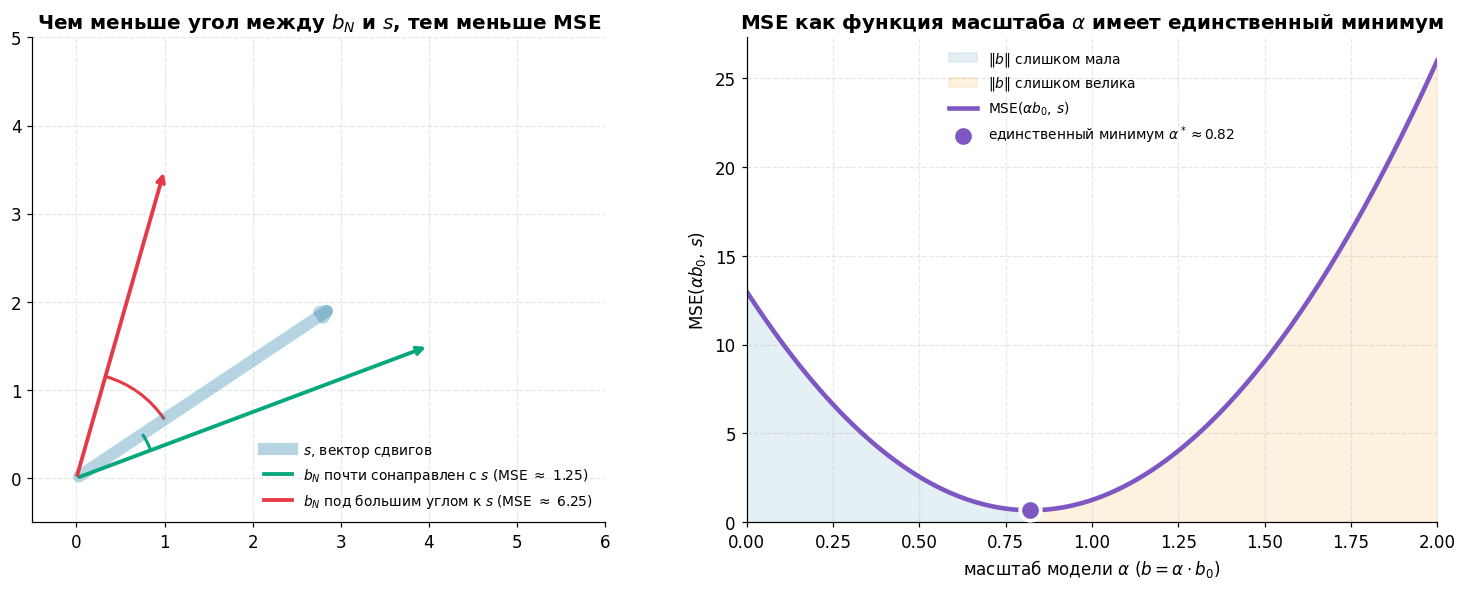

In [ ]:
# Геометрия из формулы (12): MSE раскладывается на ||b_N||² минус 2||s||·||b_N||·cos(θ) плюс const.
# Левый график связывает угол между s и b_N с величиной MSE.
# Правый показывает, что MSE как функция масштаба α имеет единственный минимум.

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
s      = np.array([3.0, 2.0])
b_good = np.array([4.0, 1.5])
b_bad  = np.array([1.0, 3.5])

mse_good = np.sum((b_good - s) ** 2)
mse_bad  = np.sum((b_bad  - s) ** 2)

ang_s    = np.degrees(np.arctan2(s[1],      s[0]))
ang_good = np.degrees(np.arctan2(b_good[1], b_good[0]))
ang_bad  = np.degrees(np.arctan2(b_bad[1],  b_bad[0]))


ax.annotate('', xy=s, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', lw=8, color=PALETTE['blue'], alpha=0.35))

ax.annotate('', xy=b_good, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', lw=2.5, color=PALETTE['green']))
ax.annotate('', xy=b_bad, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', lw=2.5, color=PALETTE['red']))

arc_good = Arc((0, 0), 1.8, 1.8,
               theta1=min(ang_s, ang_good), theta2=max(ang_s, ang_good),
               color=PALETTE['green'], lw=2)
arc_bad  = Arc((0, 0), 2.4, 2.4,
               theta1=min(ang_s, ang_bad),  theta2=max(ang_s, ang_bad),
               color=PALETTE['red'],   lw=2)
ax.add_patch(arc_good)
ax.add_patch(arc_bad)

ax.plot([], [], color=PALETTE['blue'], lw=8, alpha=0.35,
        label=r'$s$, вектор сдвигов')
ax.plot([], [], color=PALETTE['green'], lw=2.5,
        label=fr'$b_N$ почти сонаправлен с $s$ (MSE $\approx$ {mse_good:.2f})')
ax.plot([], [], color=PALETTE['red'], lw=2.5,
        label=fr'$b_N$ под большим углом к $s$ (MSE $\approx$ {mse_bad:.2f})')

ax.set_xlim(-0.5, 6)
ax.set_ylim(-0.5, 5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title(r'Чем меньше угол между $b_N$ и $s$, тем меньше MSE')
ax.legend(loc='lower right', fontsize=9, framealpha=0.95)

ax = axes[1]
b0       = b_good
b0_norm  = np.linalg.norm(b0)
s_norm   = np.linalg.norm(s)
cos_b0_s = np.dot(b0, s) / (b0_norm * s_norm)

alphas    = np.linspace(0.0, 2.0, 300)
# MSE(α·b₀, s) = α²||b₀||² − 2α·||b₀||·||s||·cos(θ) + ||s||²
mse_curve = alphas**2 * b0_norm**2 - 2 * alphas * b0_norm * s_norm * cos_b0_s + s_norm**2


alpha_opt = s_norm * cos_b0_s / b0_norm
mse_min   = s_norm**2 * (1 - cos_b0_s**2)   # ||s||²·sin²(θ)


ax.fill_between(alphas, 0, mse_curve, where=(alphas <= alpha_opt),
                color=PALETTE['blue'],   alpha=0.12,
                label=r'$\|b\|$ слишком мала')
ax.fill_between(alphas, 0, mse_curve, where=(alphas >= alpha_opt),
                color=PALETTE['orange'], alpha=0.12,
                label=r'$\|b\|$ слишком велика')

ax.plot(alphas, mse_curve, color=PALETTE['purple'], lw=3,
        label=r'MSE$(\alpha b_0,\, s)$')

ax.scatter([alpha_opt], [mse_min], color=PALETTE['purple'],
           s=180, zorder=6, edgecolor='white', linewidth=2.5,
           label=fr'единственный минимум $\alpha^* \approx {alpha_opt:.2f}$')
ax.plot([alpha_opt, alpha_opt], [0, mse_min],
        color=PALETTE['purple'], ls=':', lw=1.5, alpha=0.6)

ax.set_xlabel(r'масштаб модели $\alpha$ ($b = \alpha \cdot b_0$)')
ax.set_ylabel(r'MSE$(\alpha b_0,\, s)$')
ax.set_xlim(0, 2.0)
ax.set_ylim(0, mse_curve.max() * 1.05)
ax.grid(True, alpha=0.3)
ax.set_title(r'MSE как функция масштаба $\alpha$ имеет единственный минимум')
ax.legend(loc='upper center', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.show()

**Суть**: MSE из формулы (12) одновременно проверяет две вещи. Левый график про **направление**: чем шире дуга между $b_N$ и $s$, тем больше MSE ($1.25$ у зелёного против $6.25$ у красного), и это работает $\cos$-член. Правый график про **длину**: даже при правильно угаданном направлении остаётся один свободный параметр $\alpha$, и слагаемое $\|b\|^2$ выбирает из всех возможных длин ровно одну оптимальную, $\alpha^* \approx 0.82$. Без этого регуляризатора любая длина была бы одинаково хорошей, и оптимизация ушла бы в бесконечность.

### А почему именно квадрат отклонения, а не модуль?

Здесь полезна такая интуиция. Если сдвиг $s_i$ велик по модулю, значит на объекте $x_i$ мы можем существенно снизить ошибку, поменяв прогноз композиции. То есть **в больших $s_i$ лежит потенциальная выгода**, и базовая модель должна на них сфокусироваться.

MSE как раз так и устроена: она сильно штрафует за крупные отклонения, поэтому модель будет стремиться не промахиваться на больших $s_i$. А вот MAE может удобно подогнать кучу мелких сдвигов, а на крупных провалиться.

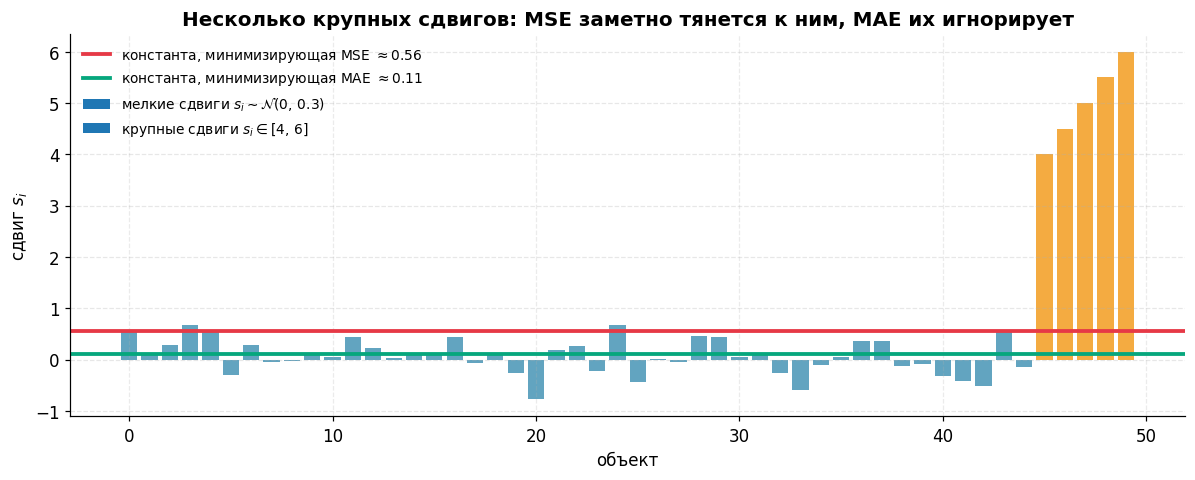

Среднее (MSE-оптимум):   0.559
Медиана (MAE-оптимум):   0.107
Разрыв между константами: 0.452


In [ ]:
# MSE vs MAE на сдвигах: что произойдёт, если среди сдвигов есть несколько крупных
np.random.seed(0)
small_shifts = np.random.normal(0, 0.3, 45)
big_shifts   = np.array([4.0, 4.5, 5.0, 5.5, 6.0])
shifts = np.concatenate([small_shifts, big_shifts])

c_mse = shifts.mean()           # константа, минимизирующая MSE = среднее
c_mae = np.median(shifts)       # константа, минимизирующая MAE = медиана

fig, ax = plt.subplots(figsize=(11, 4.5))
xs = np.arange(len(shifts))

bar_colors = [PALETTE['blue']] * len(small_shifts) + [PALETTE['orange']] * len(big_shifts)
ax.bar(xs, shifts, color=bar_colors, alpha=0.75)

ax.axhline(c_mse, color=PALETTE['red'], lw=2.5,
           label=fr'константа, минимизирующая MSE $\approx {c_mse:.2f}$')
ax.axhline(c_mae, color=PALETTE['green'], lw=2.5,
           label=fr'константа, минимизирующая MAE $\approx {c_mae:.2f}$')

ax.bar([], [], color=PALETTE['blue'],   alpha=0.75,
       label=r'мелкие сдвиги $s_i \sim \mathcal{N}(0,\,0.3)$')
ax.bar([], [], color=PALETTE['orange'], alpha=0.75,
       label=r'крупные сдвиги $s_i \in [4,\,6]$')

ax.set_title('Несколько крупных сдвигов: MSE заметно тянется к ним, MAE их игнорирует')
ax.set_xlabel('объект')
ax.set_ylabel(r'сдвиг $s_i$')
ax.legend(loc='upper left', fontsize=9, framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f'Среднее (MSE-оптимум):   {c_mse:.3f}')
print(f'Медиана (MAE-оптимум):   {c_mae:.3f}')
print(f'Разрыв между константами: {c_mse - c_mae:.3f}')

**Суть**: на 45 мелких сдвигах ($s_i \sim \mathcal{N}(0, 0.3)$) и пяти крупных (от $4$ до $6$) константа, минимизирующая MSE, заметно сдвигается в сторону крупных значений, а минимизирующая MAE остаётся почти на нуле. Разрыв между двумя константами теперь хорошо виден на глаз. В переводе на бустинг: базовый алгоритм, обученный по MSE, фокусируется на объектах с большим $|s_i|$ (там можно снять реальную ошибку композиции), а обученный по MAE их проигнорирует и подгонит «среднее мелких».

## §1.3 Почему нельзя просто обучить одно глубокое дерево?

Понятно, что если делать это неаккуратно, дерево переобучится. Но казалось бы, можно ведь контролировать переобучение через ограничение глубины или минимальное число объектов в листе.

На практике эти ограничения слишком грубые. Они не гарантируют хороший результат на тесте, поэтому пришлось бы во время построения дерева смотреть на тестовую ошибку и в каждой вершине принимать решение, продолжать ли разбивать. Более того, дерево строится **жадно**, поэтому неудачное разбиение в начале может потребовать радикальной перестройки.

Бустинг же позволяет балансировать сложность и качество естественным образом. Каждое отдельное дерево короткое и слабое, поэтому сильной подгонки не возникает. После добавления каждого нового дерева можно следить за ошибкой на отложенной выборке, и в момент, когда начинается переобучение, остановиться.

Сравним поведение одного глубокого дерева и бустинга на шумных данных:

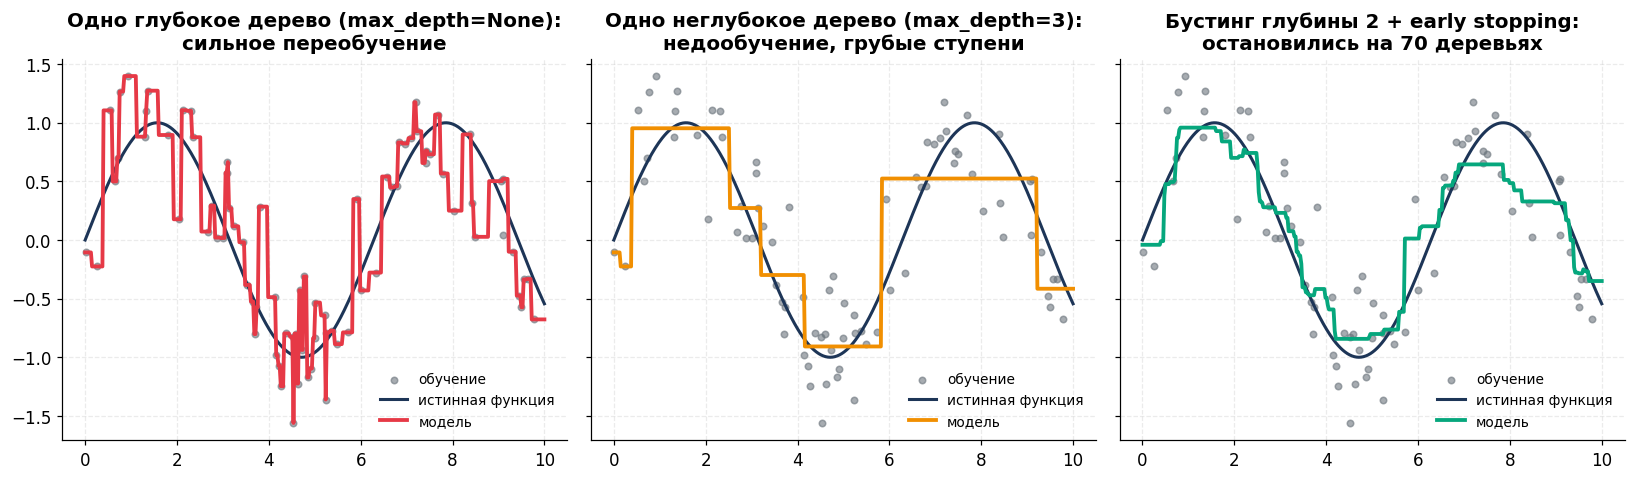

In [ ]:
# Демонстрация: одно глубокое дерево против бустинга на шумных данных
np.random.seed(7)
X_dem = np.sort(np.random.uniform(0, 10, 80)).reshape(-1, 1)
y_dem = np.sin(X_dem.ravel()) + np.random.normal(0, 0.4, len(X_dem))

X_test = np.linspace(0, 10, 400).reshape(-1, 1)
y_test_true = np.sin(X_test.ravel())

deep_tree    = DecisionTreeRegressor(max_depth=None).fit(X_dem, y_dem)
shallow_tree = DecisionTreeRegressor(max_depth=3).fit(X_dem, y_dem)

boost = GradientBoostingRegressor(
    n_estimators=500, max_depth=2, learning_rate=0.05, subsample=0.7,
    validation_fraction=0.2, n_iter_no_change=30, tol=1e-4, random_state=0
).fit(X_dem, y_dem)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

models = [
    (deep_tree,    'Одно глубокое дерево (max_depth=None):\nсильное переобучение',                       PALETTE['red']),
    (shallow_tree, 'Одно неглубокое дерево (max_depth=3):\nнедообучение, грубые ступени',                PALETTE['orange']),
    (boost,        f'Бустинг глубины 2 + early stopping:\nостановились на {boost.n_estimators_} деревьях', PALETTE['green']),
]
for ax, (m, title, c) in zip(axes, models):
    ax.scatter(X_dem, y_dem, color=PALETTE['gray'], s=18, alpha=0.6, label='обучение')
    ax.plot(X_test, y_test_true, color=PALETTE['dark'], lw=2, label='истинная функция')
    ax.plot(X_test, m.predict(X_test), color=c, lw=2.5, label='модель')
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=9, framealpha=0.92)

plt.tight_layout()
plt.show()

## §1.1 (продолжение). Можно ли задействовать идеи из модификаций градиентного спуска?

Да. Дальше в курсе мы обсудим, как использовать **вторые производные** функции потерь для имитации оптимизации второго порядка, это лежит в основе XGBoost. Но идеи можно брать и из других мест, например **метод инерции Нестерова**.

Обычный метод инерции:

$$
\begin{aligned}
h_0 &= 0,\\
h_k &= \alpha h_{k-1} + \eta_k \nabla_w Q(w^{(k-1)}),\\
w^{(k)} &= w^{(k-1)} - h_k.
\end{aligned}
\tag{13}
$$

где $w^{(k)}$ – параметры модели на шаге $k$, $Q$ – оптимизируемый функционал, $\nabla_w Q$ – его градиент по параметрам, $h_k$ – накапливаемое инерционное направление, $\alpha \in [0, 1)$ – коэффициент инерции, $\eta_k$ – шаг обучения.

Идея Нестерова в том, что мы уже знаем, что собираемся сдвинуться в направлении $h_{k-1}$. Так давайте сначала и сдвинемся, а градиент посчитаем уже из новой точки:

$$
\begin{aligned}
h_k &= \alpha h_{k-1} + \eta_k \nabla_w Q(w^{(k-1)} - \alpha h_{k-1}),\\
w^{(k)} &= w^{(k-1)} - h_k.
\end{aligned}
\tag{14}
$$

Отличие от (13) единственное: градиент считается не в текущей точке $w^{(k-1)}$, а в «забежавшей вперёд» $w^{(k-1)} - \alpha h_{k-1}$.

Перенесём идею на бустинг. Дополнительно к самой композиции $a_N(x)$ будем строить инерционную модель $h_N(x)$. Инициализируем $h_0 = a_0$. После $N-1$ шага у нас есть $a_{N-1}$ и $h_{N-1}$. Базовую модель обучаем на сдвиги из «забегания вперёд»:

$$
s_i = -\left.\frac{\partial L(y_i, z)}{\partial z}\right|_{z = a_{N-1}(x_i) + \alpha h_{N-1}(x_i)}. \tag{15}
$$

где $h_{N-1}$ – инерционная модель с прошлого шага, а антиградиент функции потерь теперь считается не в самой композиции $a_{N-1}(x_i)$, а в её сдвиге на $\alpha h_{N-1}(x_i)$. Это и есть тот самый «прыжок вперёд» из (14), просто перенесённый из пространства параметров $w$ в пространство значений прогноза $z$.

И обновляем:

$$
\begin{aligned}
h_N(x) &= \alpha h_{N-1}(x) + \eta b_N(x),\\
a_N(x) &= a_{N-1}(x) + h_N(x).
\end{aligned}
\tag{16}
$$

где $b_N$ – очередное базовое дерево, обученное приближать сдвиги $s_i$ из (15), $h_N$ – накопленное к шагу $N$ инерционное направление, $\eta$ – шаг обучения (аналог $\eta_k$ из (13)). Знак $+$ перед $h_N$ в обновлении $a_N$ согласован с тем, что $b_N$ приближает антиградиент (то есть уже учитывает минус из (15)).

В оригинальной работе используются ещё уточнения, но главная мысль такая: идеи из оптимизации действительно переносятся на бустинг.

**Суть**: метод Нестерова в бустинге состоит в том, что перед вычислением антиградиента мы «забегаем вперёд» на $\alpha h_{N-1}$ по уже накопленному инерционному направлению. Базовое дерево учится корректировать не текущую композицию $a_{N-1}$, а её прогноз с учётом инерции, и шаги получаются более «дальновидными».

Покажем разницу между обычным градиентным спуском и Нестеровым на простой 2D задаче:

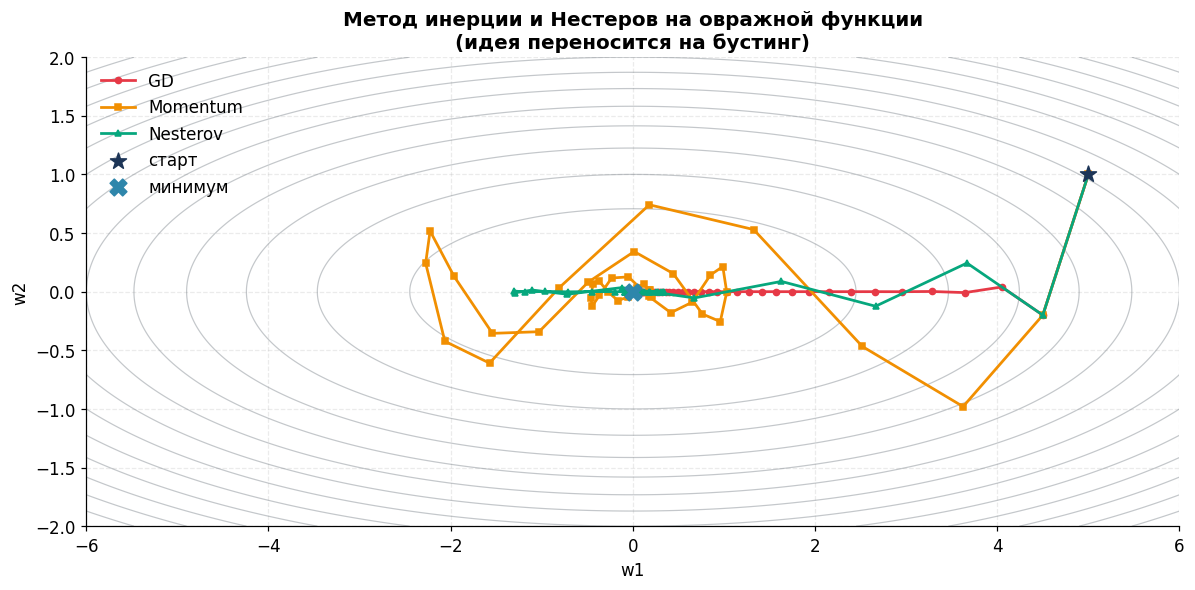

In [ ]:
# 2D пример: овражная квадратичная функция, обычный GD vs Nesterov
def f(w):
    return 0.5 * (w[0] ** 2 + 12 * w[1] ** 2)

def grad(w):
    return np.array([w[0], 12 * w[1]])

def gd(start, lr=0.1, steps=40):
    w = start.copy(); traj = [w.copy()]
    for _ in range(steps):
        w = w - lr * grad(w); traj.append(w.copy())
    return np.array(traj)

def momentum(start, lr=0.1, alpha=0.85, steps=40):
    w = start.copy(); h = np.zeros_like(w); traj = [w.copy()]
    for _ in range(steps):
        h = alpha * h + lr * grad(w)
        w = w - h; traj.append(w.copy())
    return np.array(traj)

def nesterov(start, lr=0.1, alpha=0.85, steps=40):
    w = start.copy(); h = np.zeros_like(w); traj = [w.copy()]
    for _ in range(steps):
        h = alpha * h + lr * grad(w - alpha * h)
        w = w - h; traj.append(w.copy())
    return np.array(traj)

start = np.array([5.0, 1.0])
t_gd = gd(start)
t_mom = momentum(start)
t_nes = nesterov(start)

# Контуры
g1 = np.linspace(-6, 6, 200); g2 = np.linspace(-2, 2, 200)
G1, G2 = np.meshgrid(g1, g2)
Z = 0.5 * (G1 ** 2 + 12 * G2 ** 2)

fig, ax = plt.subplots(figsize=(11, 5.5))
cs = ax.contour(G1, G2, Z, levels=15, colors=PALETTE['gray'], alpha=0.4, linewidths=0.8)
ax.plot(t_gd[:,0],  t_gd[:,1],  'o-', color=PALETTE['red'],   lw=1.8, ms=4, label='GD')
ax.plot(t_mom[:,0], t_mom[:,1], 's-', color=PALETTE['orange'], lw=1.8, ms=4, label='Momentum')
ax.plot(t_nes[:,0], t_nes[:,1], '^-', color=PALETTE['green'],  lw=1.8, ms=4, label='Nesterov')
ax.scatter(*start, color=PALETTE['dark'], s=120, marker='*', zorder=5, label='старт')
ax.scatter(0, 0, color=PALETTE['blue'], s=120, marker='X', zorder=5, label='минимум')
ax.set_title('Метод инерции и Нестеров на овражной функции\n(идея переносится на бустинг)')
ax.set_xlabel('w1'); ax.set_ylabel('w2')
ax.legend()
plt.tight_layout()
plt.show()

## §1.1 (окончание). Если бустинг такой мощный, зачем нужны другие модели?

Прежде всего, бустинг плохо работает на очень малых выборках и в задачах с огромным числом признаков (особенно когда признаков больше, чем объектов). Но есть ещё один важный нюанс: **бустинг над деревьями не умеет экстраполировать**.

Пусть один признак, и зависимость на самом деле линейная: $y(x) = ax + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, \sigma^2)$. На обучении $x \in [0, 10]$, в production может прийти $x \in [20, 30]$.

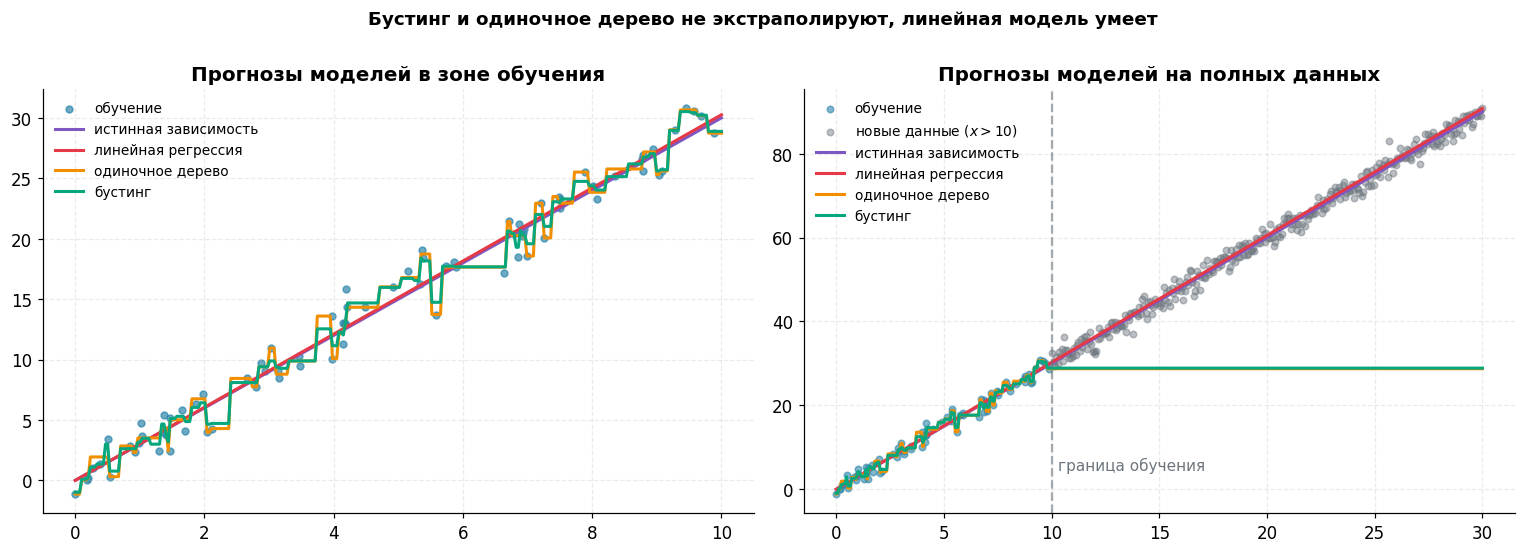

In [ ]:
# Сравнение линейной модели, одного дерева и бустинга
np.random.seed(1)
X_train = np.random.uniform(0, 10, 80).reshape(-1, 1)
y_train = 3.0 * X_train.ravel() + np.random.normal(0, 1.5, 80)

X_full = np.linspace(0, 30, 500).reshape(-1, 1)
y_full_true = 3.0 * X_full.ravel()
y_full_obs  = y_full_true + np.random.normal(0, 1.5, 500)

lin   = LinearRegression().fit(X_train, y_train)
tree  = DecisionTreeRegressor(max_depth=6, random_state=0).fit(X_train, y_train)
boost = GradientBoostingRegressor(
    n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0
).fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
xs = np.linspace(0, 10, 300).reshape(-1, 1)
ax.scatter(X_train, y_train, color=PALETTE['blue'], s=20, alpha=0.7, label='обучение')
ax.plot(xs, 3 * xs.ravel(),    color=PALETTE['purple'], lw=2, label='истинная зависимость')
ax.plot(xs, lin.predict(xs),   color=PALETTE['red'],    lw=2, label='линейная регрессия')
ax.plot(xs, tree.predict(xs),  color=PALETTE['orange'], lw=2, label='одиночное дерево')
ax.plot(xs, boost.predict(xs), color=PALETTE['green'],  lw=2, label='бустинг')
ax.set_title('Прогнозы моделей в зоне обучения')
ax.legend(loc='upper left', fontsize=9, framealpha=0.92)

ax = axes[1]
ax.scatter(X_train, y_train, color=PALETTE['blue'], s=18, alpha=0.6, label='обучение')

ax.scatter(X_full[X_full.ravel() > 10], y_full_obs[X_full.ravel() > 10],
           color=PALETTE['gray'], s=18, alpha=0.45, label=r'новые данные ($x > 10$)')
ax.plot(X_full, y_full_true,           color=PALETTE['purple'], lw=2, label='истинная зависимость')
ax.plot(X_full, lin.predict(X_full),   color=PALETTE['red'],    lw=2, label='линейная регрессия')
ax.plot(X_full, tree.predict(X_full),  color=PALETTE['orange'], lw=2, label='одиночное дерево')
ax.plot(X_full, boost.predict(X_full), color=PALETTE['green'],  lw=2, label='бустинг')
ax.axvline(10, color=PALETTE['gray'], ls='--', alpha=0.6)
ax.text(10.3, max(y_full_true) * 0.05, 'граница обучения', color=PALETTE['gray'], fontsize=10)
ax.set_title('Прогнозы моделей на полных данных')
ax.legend(loc='upper left', fontsize=9, framealpha=0.92)

plt.suptitle('Бустинг и одиночное дерево не экстраполируют, линейная модель умеет',
             fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

Видно, что и одиночное дерево, и бустинг за пределами обучения упираются в горизонтальную полку (каждый на своём уровне, в зависимости от значения последнего листа, накрывающего правый край обучения). Сколько бы деревьев ни добавляли в композицию, ни одно из них не может разбить признак за $x = 10$, потому что такой точки на обучении просто не было. Линейная регрессия же продолжает прогноз согласно общему тренду. На практике это иногда решают комбинацией: линейная модель ловит общий тренд, а бустинг корректирует остатки.

## §1.2 Сложность обучения бустинга

**Задача.** Дана выборка из $\ell$ объектов и $d$ признаков. Найдём асимптотику обучения и предсказания для композиции $a_N(x) = \sum_{n=0}^{N} b_n(x)$ над деревьями глубины не более $D$.

**Решение.** Для обучения нужно построить $N$ деревьев, поэтому всё сводится к стоимости одного дерева $T_{tree}$.

Внутри одного дерева на каждом уровне $i$ обозначим $\ell^i_j$ количество объектов, попадающих в вершину $j$ этого уровня. Чтобы найти оптимальное разбиение в вершине, нужно перебрать $d$ признаков и для каждого посмотреть $\ell^i_j - 1$ возможных порогов. С предварительной сортировкой и онлайновым пересчётом статистик это занимает $O(d \cdot \ell^i_j)$.

По принципу сохранения объектов на одном уровне в сумме лежит ровно $\ell$ объектов:

$$
\sum_{j=1}^{2^i} \ell^i_j = \ell. \tag{17}
$$

где сумма берётся по всем не более чем $2^i$ вершинам уровня $i$, и тождество выполнено просто потому, что каждый из $\ell$ объектов на любом уровне попадает ровно в одну вершину.

Значит на один уровень тратится $O(d\ell)$, а уровней всего $D$. Получаем стоимость одного дерева:

$$
T_{tree} = O(D \cdot d \cdot \ell). \tag{18}
$$

Итоговая сложность обучения:

$$
\boxed{O(N \cdot D \cdot d \cdot \ell)} \tag{19}
$$

где $N$ – число деревьев в композиции, $D$ – ограничение на глубину дерева, $d$ – число признаков, $\ell$ – размер обучающей выборки. Зависимость линейна по каждому из четырёх параметров.

Прогноз: объект проходит путь длины не более $D$, в каждой вершине константная проверка. Сложность предсказания на одном объекте:

$$
\boxed{O(N \cdot D)} \tag{20}
$$

Зависимости от размера обучающей выборки $\ell$ здесь уже нет: обученные деревья работают как фиксированный набор сравнений и в момент инференса исходные данные не нужны.

**Суть**: обучение бустинга линейно по всем четырём параметрам: числу деревьев $N$, глубине $D$, числу признаков $d$ и размеру выборки $\ell$. Прогноз же не зависит от $\ell$ вообще и стоит всего $O(N D)$ на объект. Поэтому бустинг легко позволяет себя обучать на крупных датасетах и при этом остаётся быстрым в продакшене.

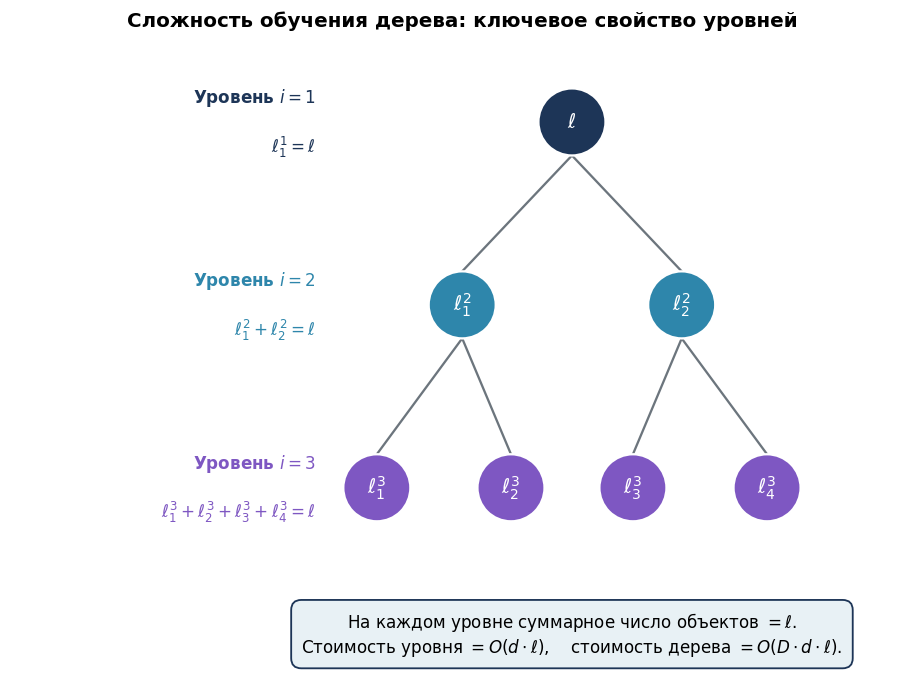

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))

levels = [
    [(0.50, 0.88, r'$\ell$')],
    [(0.32, 0.58, r'$\ell^2_1$'),  (0.68, 0.58, r'$\ell^2_2$')],
    [(0.18, 0.28, r'$\ell^3_1$'),  (0.40, 0.28, r'$\ell^3_2$'),
     (0.60, 0.28, r'$\ell^3_3$'),  (0.82, 0.28, r'$\ell^3_4$')],
]

# рёбра
def draw_edges(parents, children_groups):
    for (px, py, _), kids in zip(parents, children_groups):
        for (cx, cy, _) in kids:
            ax.plot([px, cx], [py - 0.055, cy + 0.055],
                    color=PALETTE['gray'], lw=1.5, zorder=1)

draw_edges(levels[0], [levels[1]])
draw_edges(levels[1], [levels[2][:2], levels[2][2:]])

# узлы
node_colors = [PALETTE['dark'], PALETTE['blue'], PALETTE['purple']]
for level, color in zip(levels, node_colors):
    for x, y, label in level:
        ax.add_patch(Circle((x, y), 0.055, facecolor=color,
                            edgecolor='white', lw=1.5, zorder=3))
        ax.text(x, y, label, ha='center', va='center', color='white',
                fontsize=13, fontweight='bold', zorder=4)

LABEL_X_RIGHT = 0.08
level_descriptions = [
    (0.88, r'Уровень $i = 1$', r'$\ell^1_1 = \ell$',                                  PALETTE['dark']),
    (0.58, r'Уровень $i = 2$', r'$\ell^2_1 + \ell^2_2 = \ell$',                       PALETTE['blue']),
    (0.28, r'Уровень $i = 3$', r'$\ell^3_1 + \ell^3_2 + \ell^3_3 + \ell^3_4 = \ell$', PALETTE['purple']),
]
for y, header, eq, color in level_descriptions:
    ax.text(LABEL_X_RIGHT, y + 0.040, header, va='center', ha='right',
            fontsize=11, color=color, fontweight='bold')
    ax.text(LABEL_X_RIGHT, y - 0.040, eq, va='center', ha='right',
            fontsize=11, color=color)

ax.text(0.50, 0.04,
        r'На каждом уровне суммарное число объектов $= \ell$.' + '\n' +
        r'Стоимость уровня $= O(d \cdot \ell)$,    стоимость дерева $= O(D \cdot d \cdot \ell).$',
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.6', fc='#e8f1f5', ec=PALETTE['dark'], lw=1.2))

ax.set_xlim(-0.42, 1.06)
ax.set_ylim(-0.05, 1.00)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Сложность обучения дерева: ключевое свойство уровней',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Что быстрее, бустинг или бэггинг?

Чёткого ответа нет. В бустинге используются неглубокие деревья, и из-за направленности обучения может хватить меньшего числа деревьев. Но в бэггинге деревья независимы и обучаются параллельно, чего в бустинге нет: $N$-е дерево не построить, пока не готовы все предыдущие. Обычно в бустинге распараллеливают только перебор предикатов, но это можно делать и в бэггинге.

# Часть 2. Промышленные реализации бустинга

До сих пор мы обсуждали базовый градиентный бустинг и интуицию за каждым его блоком. На практике используются улучшенные версии. Посмотрим на три главных:

* **XGBoost**: вторые производные, регуляризация, специальный критерий разбиения, поиск с учётом разрежённости.
* **LightGBM**: GOSS (отбор объектов по градиентам), EFB (склеивание признаков), leaf-wise рост.
* **CatBoost**: oblivious decision trees, упорядоченный бустинг, особая обработка категориальных.

## §2. Extreme Gradient Boosting (XGBoost)

### §2.1 Кратко о возможностях

Градиентный бустинг в XGBoost имеет следующие особенности (подробнее они разбирались на лекции):

* Базовый алгоритм приближает направление, посчитанное **с использованием вторых производных** функции потерь.
* Функционал регуляризуется: штраф за **количество листьев** и за **норму коэффициентов** в листьях.
* При построении дерева используется критерий информативности, **зависящий от оптимального вектора сдвига**.
* Критерий останова при обучении дерева тоже зависит от оптимального сдвига.

В итоге получается формула, которую мы максимизируем на каждой вершине при выборе разбиения:

$$
\boxed{\;
\mathcal{L}_{\text{split}} = \frac{1}{2}\!\left[
\frac{\bigl(\sum_{i\in R_l} s_i\bigr)^2}{\sum_{i\in R_l} h_i + \lambda}
+ \frac{\bigl(\sum_{i\in R_r} s_i\bigr)^2}{\sum_{i\in R_r} h_i + \lambda}
– \frac{\bigl(\sum_{i\in R} s_i\bigr)^2}{\sum_{i\in R} h_i + \lambda}
\right] - \gamma
\;}
\tag{21}
$$

Здесь:

* $s_i = –\partial L(y_i, z)/\partial z$ это первая производная функции потерь, вычисленная в текущем прогнозе $z = a_{N-1}(x_i)$,
* $h_i = \partial^2 L(y_i, z)/\partial z^2$ это вторая производная,
* $R$ это объекты в текущей вершине, $R_l$ и $R_r$ это разбиение,
* $\lambda$ это регуляризация за норму прогнозов в листьях,
* $\gamma$ это штраф за создание дополнительного листа.

XGBoost всё равно обучает дерево, поэтому у него остаётся **главная проблема: как искать оптимальное разбиение в каждой вершине**. Особенно если данных много или мы хотим распределить обучение по машинам. Дальше посмотрим три подхода к её решению.

**Суть**: XGBoost вычисляет аналитический выигрыш от любого разбиения через первую $s_i$ и вторую $h_i$ производные функции потерь с двумя видами регуляризации ($\lambda$ внутри дробей, $\gamma$ снаружи). Сплит делается, только если $\mathcal{L}_{\text{split}} > 0$. Когда для вершины не нашлось ни одного разбиения с таким свойством, дерево перестаёт расти, и это уже встроенный в формулу механизм ранней остановки.

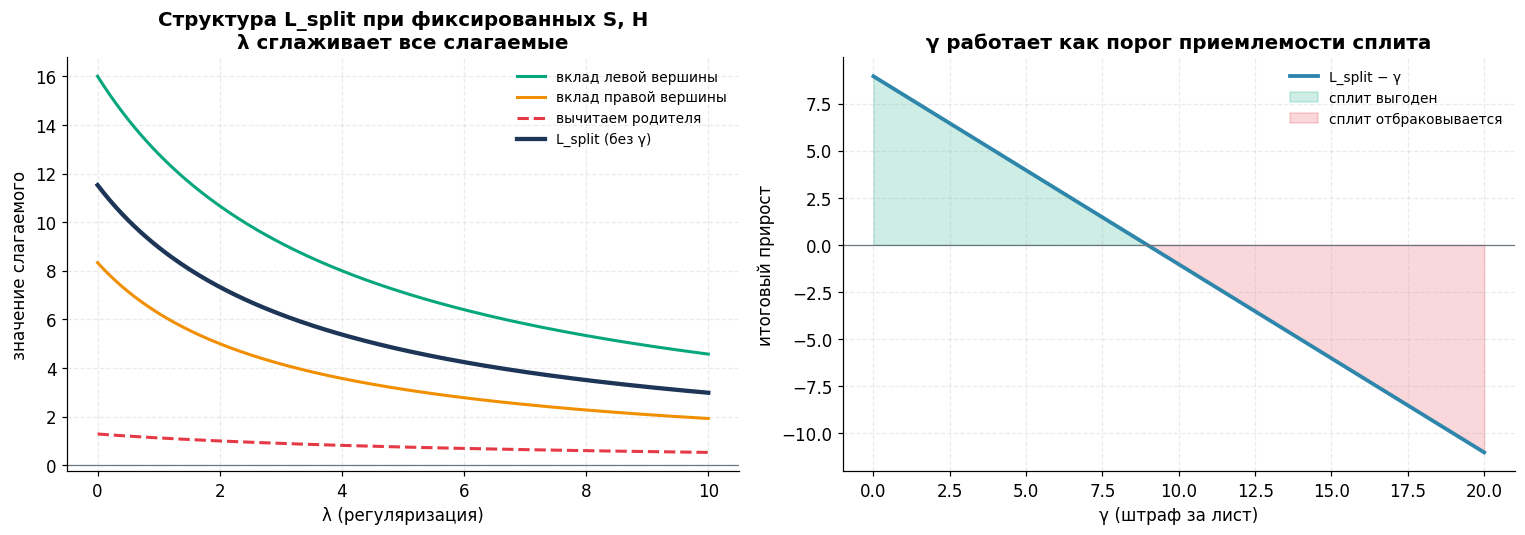

In [ ]:
# Визуализируем структуру формулы L_split
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
S_l, H_l = 8.0, 4.0
S_r, H_r = -5.0, 3.0
S_p, H_p = S_l + S_r, H_l + H_r
lams = np.linspace(0, 10, 200)

left = (S_l ** 2) / (H_l + lams)
right = (S_r ** 2) / (H_r + lams)
parent = (S_p ** 2) / (H_p + lams)
L = 0.5 * (left + right - parent)

ax.plot(lams, left,   color=PALETTE['green'],  lw=2, label='вклад левой вершины')
ax.plot(lams, right,  color=PALETTE['orange'], lw=2, label='вклад правой вершины')
ax.plot(lams, parent, color=PALETTE['red'],    lw=2, ls='--', label='вычитаем родителя')
ax.plot(lams, L,      color=PALETTE['dark'],   lw=2.8, label='L_split (без γ)')
ax.axhline(0, color=PALETTE['gray'], lw=0.8)
ax.set_xlabel('λ (регуляризация)')
ax.set_ylabel('значение слагаемого')
ax.set_title('Структура L_split при фиксированных S, H\nλ сглаживает все слагаемые')
ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
L_no_gamma = 0.5 * ((S_l**2)/(H_l+1) + (S_r**2)/(H_r+1) - (S_p**2)/(H_p+1))
gammas = np.linspace(0, 20, 200)
net_gain = L_no_gamma - gammas

ax.plot(gammas, net_gain, color=PALETTE['blue'], lw=2.5, label='L_split − γ')
ax.fill_between(gammas, 0, net_gain, where=(net_gain > 0),
                color=PALETTE['green'], alpha=0.2, label='сплит выгоден')
ax.fill_between(gammas, 0, net_gain, where=(net_gain < 0),
                color=PALETTE['red'], alpha=0.2, label='сплит отбраковывается')
ax.axhline(0, color=PALETTE['gray'], lw=0.8)
ax.set_xlabel('γ (штраф за лист)')
ax.set_ylabel('итоговый прирост')
ax.set_title('γ работает как порог приемлемости сплита')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### §2.2 Базовый подход: жадный способ разбиения

Этот вариант подходит, когда обучение запускается на одной машине и все данные помещаются в оперативную память.

Для нахождения наилучшего разбиения мы смотрим **все возможные разбиения** объектов в вершине на две подгруппы. Чтобы делать это эффективно:

1. Сортируем объекты по значению рассматриваемого признака.
2. Идём по отсортированному списку слева направо, поддерживая онлайн-суммы $S_L, H_L$.
3. Для каждого порога считаем $\mathcal{L}_{\text{split}}$, запоминаем максимум.

#### Алгоритм 1. Точный жадный поиск сплита

```
Вход: I, набор объектов в текущей вершине
Вход: d, размерность пространства признаков

1.  S ← Σ_{i∈I} s_i,    H ← Σ_{i∈I} h_i
2.  for k = 1 to d:
3.      S_L ← 0,  H_L ← 0
4.      for j in sorted(I, by x_jk):
5.          S_L ← S_L + s_j,   H_L ← H_L + h_j
6.          S_R ← S − S_L,     H_R ← H − H_L
7.          score ← max(score,  S_L²/(H_L+λ) + S_R²/(H_R+λ) − S²/(H+λ))
8.      end
9.  end
10. Return: разбиение с максимальным score
```

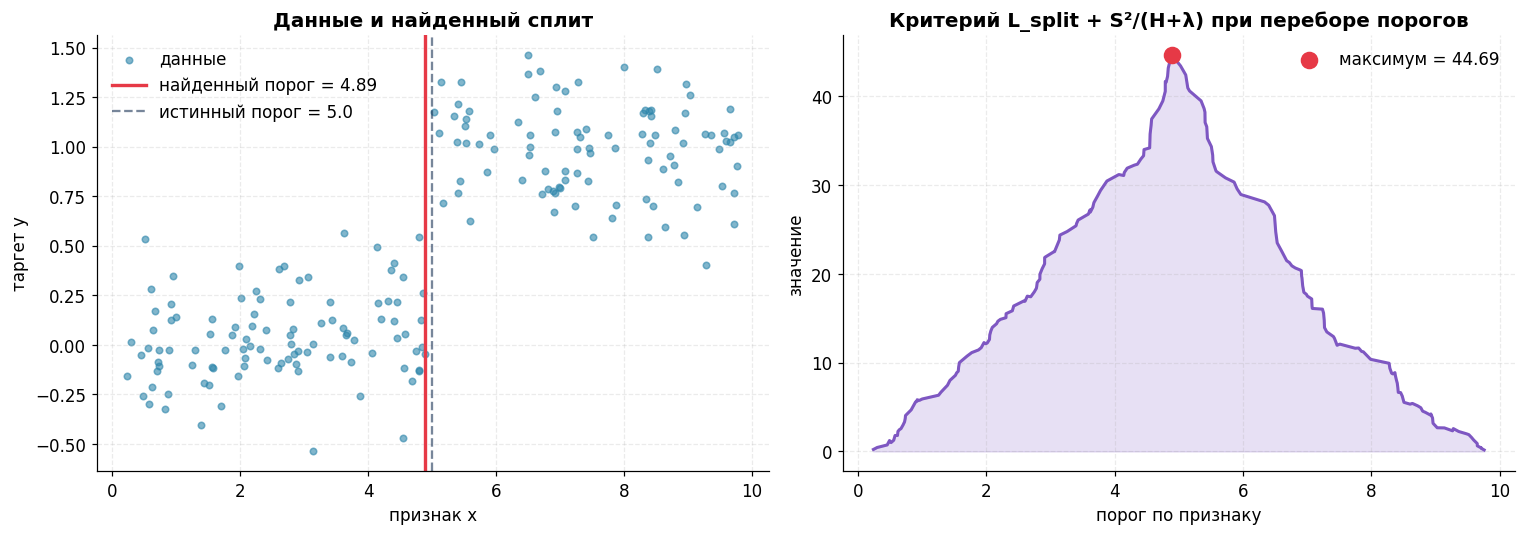

In [ ]:
# Реализация точного жадного поиска
np.random.seed(3)
n_obj = 200
x_feat = np.sort(np.random.uniform(0, 10, n_obj))
target = (x_feat > 5).astype(float) + np.random.normal(0, 0.2, n_obj)

a_prev = target.mean()
s_arr = target - a_prev
h_arr = np.ones_like(s_arr)
lam = 1.0

S_tot, H_tot = s_arr.sum(), h_arr.sum()
S_L_arr = np.cumsum(s_arr)
H_L_arr = np.cumsum(h_arr)
S_R_arr = S_tot - S_L_arr
H_R_arr = H_tot - H_L_arr

scores = (S_L_arr ** 2) / (H_L_arr + lam) \
       + (S_R_arr ** 2) / (H_R_arr + lam) \
       - (S_tot ** 2) / (H_tot + lam)
valid_scores = scores[:-1]
best_idx = int(np.argmax(valid_scores))
best_thr = x_feat[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(x_feat, target, color=PALETTE['blue'], s=18, alpha=0.6, label='данные')
ax.axvline(best_thr, color=PALETTE['red'], lw=2.2,
           label=f'найденный порог = {best_thr:.2f}')
ax.axvline(5, color=PALETTE['dark'], ls='--', alpha=0.6,
           label='истинный порог = 5.0')
ax.set_title('Данные и найденный сплит')
ax.set_xlabel('признак x'); ax.set_ylabel('таргет y')
ax.legend()

ax = axes[1]
ax.plot(x_feat[:-1], valid_scores, color=PALETTE['purple'], lw=2)
ax.fill_between(x_feat[:-1], 0, valid_scores, color=PALETTE['purple'], alpha=0.18)
ax.scatter([best_thr], [valid_scores[best_idx]], color=PALETTE['red'],
           s=110, zorder=5, label=f'максимум = {valid_scores[best_idx]:.2f}')
ax.set_title('Критерий L_split + S²/(H+λ) при переборе порогов')
ax.set_xlabel('порог по признаку'); ax.set_ylabel('значение')
ax.legend()

plt.tight_layout()
plt.show()

### §2.3 Приближённый алгоритм поиска разбиения

Простой жадный подход не очень эффективен: может не хватить памяти, и для распределённого обучения он плохо подходит. Поэтому есть **приближённый алгоритм**:

1. Сначала **предлагаем точки-кандидаты** $G_k = \{g_{k1}, \dots, g_{kl}\}$ для каждого признака $k$, обычно по перцентилям.
2. **Раскладываем объекты по бакетам** между кандидатами и агрегируем статистики $S_{kv}, H_{kv}$.
3. **Применяем Алгоритм 1 поверх агрегированных бакетов**, перебирая $l$ точек вместо всех $\ell$ объектов.

#### Алгоритм 2. Приближённый поиск сплита

```
1.  for k = 1 to d:
2.      Предлагаем разбиения G_k = {g_{k1}, ..., g_{kl}} по перцентилям признака k
3.      (Глобальный подход, кандидаты на всё дерево,
         локальный, на каждую вершину свои)
4.  end
5.  for k = 1 to d:
6.      S_{kv} ← Σ_{j ∈ {j | g_{k,v} > x_jk ≥ g_{k,v-1}}}  s_j
7.      H_{kv} ← Σ_{j ∈ {j | g_{k,v} > x_jk ≥ g_{k,v-1}}}  h_j
8.  end
9.  По агрегированным статистикам применяем Алгоритм 1
    для поиска лучшего разбиения среди предложенных
```

Два подхода к работе с кандидатами:

* **Глобальный**: один набор кандидатов на всё дерево.
* **Локальный**: новый набор кандидатов в каждой вершине.

Глобальный требует меньше пересчётов, но для хорошего качества нужно **больше** кандидатов, поскольку они не уточняются после разбиений. Локальный пересматривает кандидатов после каждого сплита, что хорошо для **глубоких** деревьев.

Параметр $\varepsilon$ соответствует ширине бакета в распределении признака. Получаем $\approx 1/\varepsilon$ бакетов.

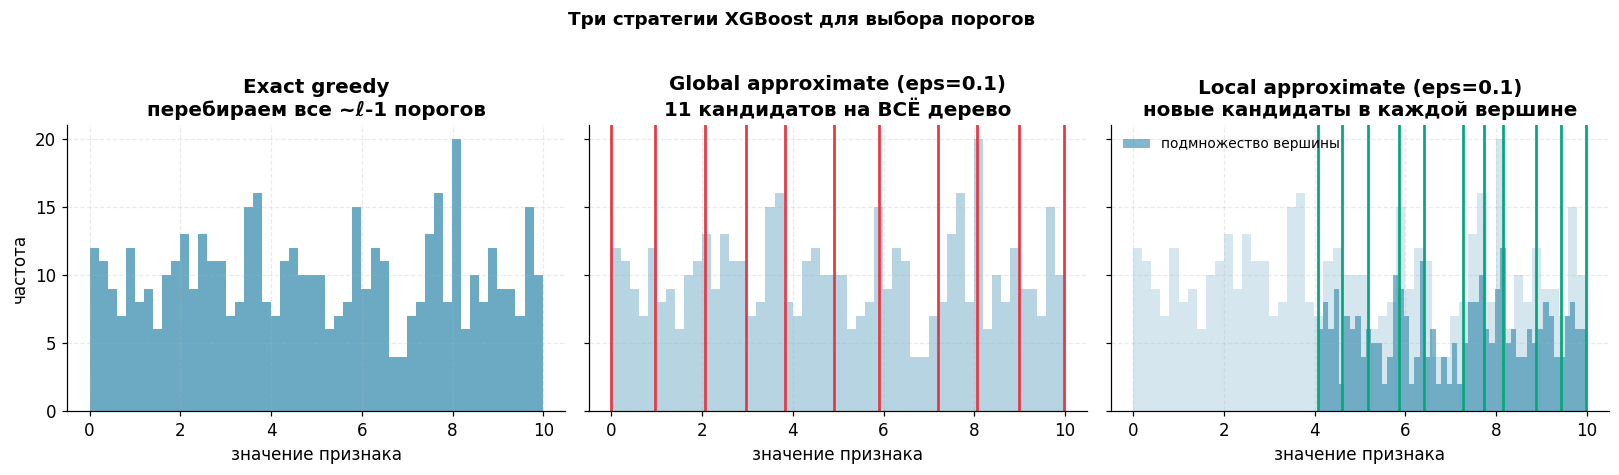

In [ ]:
# Три стратегии XGBoost для выбора порогов
np.random.seed(5)
x_sample = np.random.uniform(0, 10, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

ax = axes[0]
ax.hist(x_sample, bins=50, color=PALETTE['blue'], alpha=0.7)
ax.set_title('Exact greedy\nперебираем все ~ℓ-1 порогов')
ax.set_xlabel('значение признака')
ax.set_ylabel('частота')

ax = axes[1]
ax.hist(x_sample, bins=50, color=PALETTE['blue'], alpha=0.35)
percentiles_global = np.percentile(x_sample, np.arange(0, 101, 10))
for p in percentiles_global:
    ax.axvline(p, color=PALETTE['red'], lw=1.8)
ax.set_title(f'Global approximate (eps=0.1)\n{len(percentiles_global)} кандидатов на ВСЁ дерево')
ax.set_xlabel('значение признака')

ax = axes[2]
sub = x_sample[x_sample > 4]
ax.hist(x_sample, bins=50, color=PALETTE['blue'], alpha=0.2)
ax.hist(sub, bins=50, color=PALETTE['blue'], alpha=0.6, label='подмножество вершины')
percentiles_local = np.percentile(sub, np.arange(0, 101, 10))
for p in percentiles_local:
    ax.axvline(p, color=PALETTE['green'], lw=1.8)
ax.set_title('Local approximate (eps=0.1)\nновые кандидаты в каждой вершине')
ax.set_xlabel('значение признака')
ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Три стратегии XGBoost для выбора порогов',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### Воспроизведение рисунка 1 (сходимость AUC на бозонах Хиггса)

В семинаре показан график сравнения четырёх вариантов на датасете Higgs Boson размером 10М: точный жадный, глобальный с eps=0.3, локальный с eps=0.3, глобальный с eps=0.05. Воспроизводим его качественно.

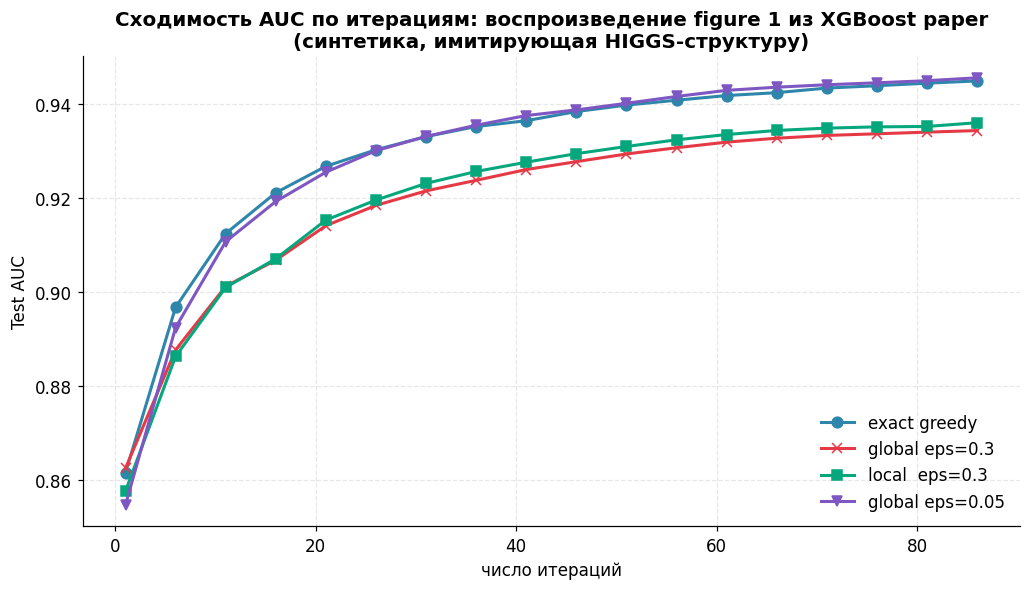


Итоговый Test AUC после 90 итераций:
  exact greedy        : 0.9453
  global eps=0.3      : 0.9346
  local  eps=0.3      : 0.9366
  global eps=0.05     : 0.9460

Выводы:
  1. local eps=0.3 догоняет exact greedy: пересчёт бакетов на каждом уровне
     спасает от грубости.
  2. global eps=0.3 заметно хуже: один и тот же грубый набор бакетов используется
     до самого низа дерева, и теряются полезные пороги в глубоких вершинах.
  3. global eps=0.05 догоняет exact, но за счёт большего числа бакетов и большего
     потребления памяти на гистограммы.


In [ ]:
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

np.random.seed(1)
X, y = make_classification(
    n_samples=300_000, n_features=28,
    n_informative=10, n_redundant=4, n_clusters_per_class=2,
    flip_y=0.08, class_sep=0.7, random_state=1,
)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=1)
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dtest  = xgb.DMatrix(X_te, label=y_te)

configs = [
    ('exact greedy',    dict(tree_method='exact'),               PALETTE['blue'],   'o'),
    ('global eps=0.3',  dict(tree_method='hist',   max_bin=3),   PALETTE['red'],    'x'),
    ('local  eps=0.3',  dict(tree_method='approx', max_bin=3),   PALETTE['green'],  's'),
    ('global eps=0.05', dict(tree_method='hist',   max_bin=20),  PALETTE['purple'], 'v'),
]

base_params = dict(
    objective='binary:logistic', eval_metric='auc',
    learning_rate=0.1, max_depth=6, seed=1, verbosity=0,
)

N_ROUNDS = 90
curves = {}
for name, extra, color, marker in configs:
    params = {**base_params, **extra}
    er = {}
    xgb.train(params, dtrain, num_boost_round=N_ROUNDS,
              evals=[(dtest, 'test')], evals_result=er, verbose_eval=False)
    curves[name] = (np.array(er['test']['auc']), color, marker)

# Сам график
fig, ax = plt.subplots(figsize=(9.5, 5.5))
iters_full = np.arange(1, N_ROUNDS + 1)
step = 5   # прореживаем для читаемости, как в paper
for name, (auc, color, marker) in curves.items():
    ax.plot(iters_full[::step], auc[::step],
            marker=marker, linestyle='-', color=color, lw=2, ms=7, label=name)

ax.set_xlabel('число итераций')
ax.set_ylabel('Test AUC')
ax.set_title('Сходимость AUC по итерациям: воспроизведение figure 1 из XGBoost paper\n'
             '(синтетика, имитирующая HIGGS-структуру)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nИтоговый Test AUC после {N_ROUNDS} итераций:')
for name, (auc, _, _) in curves.items():
    print(f'  {name:<20}: {auc[-1]:.4f}')

print('\nВыводы:')
print('  1. local eps=0.3 догоняет exact greedy: пересчёт бакетов на каждом уровне')
print('     спасает от грубости.')
print('  2. global eps=0.3 заметно хуже: один и тот же грубый набор бакетов используется')
print('     до самого низа дерева, и теряются полезные пороги в глубоких вершинах.')
print('  3. global eps=0.05 догоняет exact, но за счёт большего числа бакетов и большего')
print('     потребления памяти на гистограммы.')

Большинство существующих приближённых алгоритмов для распределённого обучения деревьев следуют этой структуре. Также можно использовать другие стратегии разбиения вместо квантилей. Главное наблюдение: квантильная стратегия может дать **ту же точность, что и алгоритм с простой жадностью при разумном значении $\varepsilon$**. Под капотом XGBoost поддерживает оба подхода.

### §2.4 Поиск сплита с учётом разрежённости данных

В реальных данных очень часто присутствует разрежённость:

* **Пропущенные значения** в данных.
* **Частые нулевые записи** в статистике.
* **Артефакты feature engineering** (например, one-hot).

Авторы XGBoost предлагают добавить в каждую вершину **направление по умолчанию** для распределения объектов с пустым значением соответствующего признака.

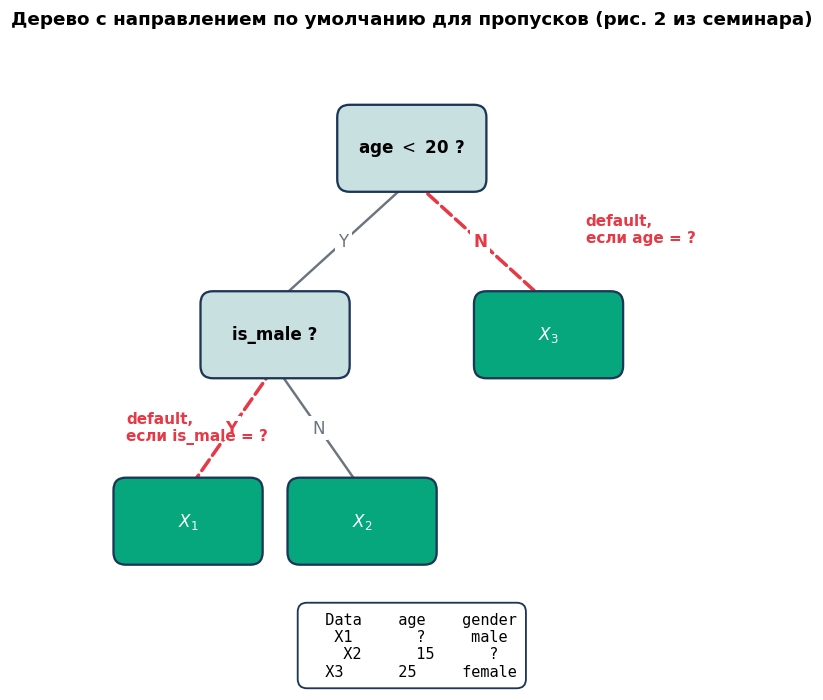

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))

NODE_FILL = '#c8e0e0'
LEAF_FILL = PALETTE['green']

def node(x, y, text, fc, text_color='black', w=0.20, h=0.10):
    ax.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h,
                                boxstyle='round,pad=0.02',
                                fc=fc, ec=PALETTE['dark'], lw=1.5, zorder=3))
    ax.text(x, y, text, ha='center', va='center',
            fontsize=11, fontweight='bold', color=text_color, zorder=4)

def edge(x1, y1, x2, y2, label='', is_default=False):
    color = PALETTE['red'] if is_default else PALETTE['gray']
    ls    = '--'           if is_default else '-'
    lw    = 2.3            if is_default else 1.6
    ax.annotate('', xy=(x2, y2 + 0.05), xytext=(x1, y1 - 0.05),
                arrowprops=dict(arrowstyle='->', lw=lw, color=color, ls=ls),
                zorder=2)
    if label:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2, label,
                fontsize=11, color=color,
                fontweight='bold' if is_default else 'normal',
                ha='center', va='center',
                bbox=dict(facecolor='white', edgecolor='none', pad=2))

# Узлы
node(0.50, 0.85, r'age $<$ 20 ?', NODE_FILL)
node(0.28, 0.55, 'is_male ?',     NODE_FILL)
node(0.72, 0.55, r'$X_3$',        LEAF_FILL, text_color='white')
node(0.14, 0.25, r'$X_1$',        LEAF_FILL, text_color='white')
node(0.42, 0.25, r'$X_2$',        LEAF_FILL, text_color='white')

# Рёбра
edge(0.50, 0.85, 0.28, 0.55, 'Y')
edge(0.50, 0.85, 0.72, 0.55, 'N', is_default=True)
edge(0.28, 0.55, 0.14, 0.25, 'Y', is_default=True)
edge(0.28, 0.55, 0.42, 0.25, 'N')

ax.text(0.78, 0.72, 'default,\nесли age = ?',
        color=PALETTE['red'], fontsize=10, fontweight='bold',
        ha='left', va='center')
ax.text(0.04, 0.40, 'default,\nесли is_male = ?',
        color=PALETTE['red'], fontsize=10, fontweight='bold',
        ha='left', va='center')

table_text = (
    '  Data    age    gender\n'
    '  X1       ?     male\n'
    '  X2      15      ?\n'
    '  X3      25     female'
)
ax.text(0.50, 0.05, table_text, ha='center', va='center',
        fontsize=10, family='monospace',
        bbox=dict(boxstyle='round,pad=0.6', fc='white',
                  ec=PALETTE['dark'], lw=1.2))

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Дерево с направлением по умолчанию для пропусков',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

Считаем нужные статистики для разбиения с учётом того, что все объекты без значения уйдут **направо** или **налево**, выбираем тот вариант, что будет оптимальнее по $\mathcal{L}_{\text{split}}$. При этом сортируем и итеративно рассматриваем **только не-пропущенные объекты**.

#### Алгоритм 3. Sparsity-aware Split Finding

```
Вход: I, набор объектов в текущей вершине
Вход: I_k = {i ∈ I : x_ik ≠ missing}, только не-пропущенные по признаку k
Вход: d, размерность пространства признаков

S ← Σ_{i∈I} s_i,    H ← Σ_{i∈I} h_i

1.  for k = 1 to d:
2.      # вариант 1: пропуски этого признака уходят НАПРАВО
3.      S_L ← 0,  H_L ← 0
4.      for j in sorted(I_k, ascending by x_jk):
5.          S_L += s_j,   H_L += h_j
6.          S_R ← S − S_L,   H_R ← H − H_L
7.          score ← max(score,  S_L²/(H_L+λ) + S_R²/(H_R+λ) − S²/(H+λ))
8.      end
9.      # вариант 2: пропуски этого признака уходят НАЛЕВО
10.     S_R ← 0,  H_R ← 0
11.     for j in sorted(I_k, descending by x_jk):
12.         S_R += s_j,   H_R += h_j
13.         S_L ← S − S_R,   H_L ← H − H_R
14.         score ← max(score,  S_L²/(H_L+λ) + S_R²/(H_R+λ) − S²/(H+λ))
15.     end
16. end
17. Return: лучшее разбиение и полученные направления по умолчанию
```

Важные детали:

* В XGBoost этим способом обрабатываются **все возможные шаблоны разрежённости**, включая нули после OHE.
* Параметр `missing` настраивается пользователем: после OHE удобно интерпретировать нули как пропуски.
* Метод даёт **линейную сложность по числу не-пропущенных значений** во всех данных, а не по общему числу объектов.

На датасете Allstate-10K (разрежённый из-за обильного OHE) sparsity-aware split работает примерно в **50 раз быстрее** наивной реализации.

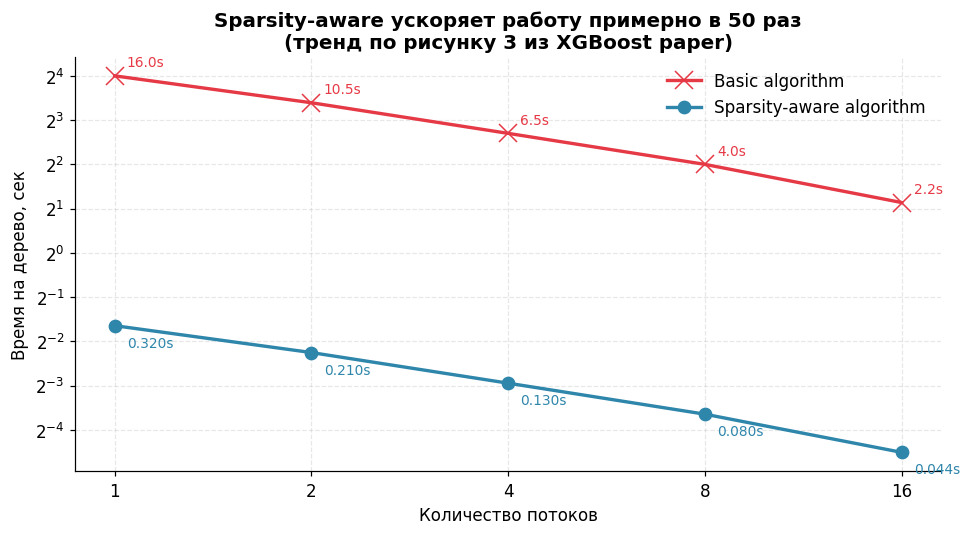

In [ ]:
# Сравнение наивного и sparsity-aware подходов (~50x как в семинаре)
threads = [1, 2, 4, 8, 16]
basic = np.array([16.0, 10.5, 6.5, 4.0, 2.2])
sparse = basic / 50.0

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threads, basic,  'x-', color=PALETTE['red'],  lw=2.2, ms=12, label='Basic algorithm')
ax.plot(threads, sparse, 'o-', color=PALETTE['blue'], lw=2.2, ms=8,  label='Sparsity-aware algorithm')

for t, b in zip(threads, basic):
    ax.annotate(f'{b:.1f}s', (t, b), textcoords="offset points",
                xytext=(8, 6), fontsize=9, color=PALETTE['red'])
for t, sp in zip(threads, sparse):
    ax.annotate(f'{sp:.3f}s', (t, sp), textcoords="offset points",
                xytext=(8, -14), fontsize=9, color=PALETTE['blue'])

ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.set_xlabel('Количество потоков')
ax.set_ylabel('Время на дерево, сек')
ax.set_title('Sparsity-aware ускоряет работу примерно в 50 раз\n(тренд по рисунку 3 из XGBoost paper)')
ax.set_xticks(threads)
ax.set_xticklabels([str(t) for t in threads])
ax.legend()
ax.grid(True, which='both', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

## §3. LightGBM

LightGBM тоже борется с необходимостью просматривать все объекты выборки для поиска лучшего разбиения. В отличие от XGBoost, авторы пытаются прийти к **меньшему числу используемых объектов** и **рассмотрению меньшего числа признаков** через два специальных подхода:

* **GOSS** (Gradient-based One-Side Sampling): отбрасывает часть объектов на основе их градиентов.
* **EFB** (Exclusive Feature Bundling): склеивает редко-конфликтующие признаки в один.

Плюс отдельная стратегия роста дерева (**leaf-wise** вместо level-wise).

### §3.1 Gradient based One-Side Sampling

Авторы обращают внимание, что объекты с разными градиентами отклонения играют разные роли в вычислении прироста информативности. Исходя из формул, **объекты с большими градиентами** (то есть те, по которым модель плохо предсказывает) вносят больший вклад в gain.

Поэтому при попытке уменьшить число рассматриваемых объектов авторы предлагают:

* **Сохранять все** экземпляры с большими градиентами (верхние $a \cdot 100\%$ по модулю).
* **Случайно отбрасывать** часть экземпляров с малыми градиентами (оставляем $b \cdot 100\%$ из оставшихся).

Чтобы компенсировать смещение распределения, при вычислении информативности **градиенты случайно выбранных малых объектов домножаются на постоянный множитель** $\dfrac{1-a}{b}$. Так суммарный вклад «малых» градиентов в gain сохраняется в среднем, хотя объектов используется меньше.

#### Алгоритм 4. Gradient-based One-Side Sampling

```
Вход: I, обучающая выборка
Вход: d, число итераций
Вход: a, коэффициент отбора больших градиентов
Вход: b, коэффициент отбора малых градиентов
Вход: loss, функция потерь
Вход: L, слабая модель (weak learner)

1.  models ← {},   fact ← (1−a)/b
2.  topN ← a · len(I),    randN ← b · len(I)
3.  for i = 1 to d:
4.      preds ← models.predict(I)
5.      g ← loss.gradient(I, preds),   w ← {1, 1, ..., 1}
6.      sorted ← GetSortedIndices(abs(g))
7.      topSet  ← sorted[1 : topN]
8.      randSet ← RandomPick(sorted[topN : end], randN)
9.      usedSet ← topSet ∪ randSet
10.     w[randSet] *= fact           # домножаем веса малых градиентов
11.     newModel ← L(I[usedSet], -g[usedSet], w[usedSet])
12.     models.append(newModel)
```

**Иллюстрация GOSS.** Покажу три вещи на одном составном графике:

1. Распределение модулей градиентов и три зоны: топ-$a$, случайная подвыборка из остатка, отброшенные.
2. Что именно делает множитель $(1-a)/b$: он применяется **к градиентам**, а не к счётчикам. Сравним истинные значения $|g|$ объектов и взвешенные $w \cdot |g|$.
3. Суммарный вклад в $\sum_i w_i |g_i|$ по группам до и после взвешивания, чтобы убедиться, что компенсация работает.

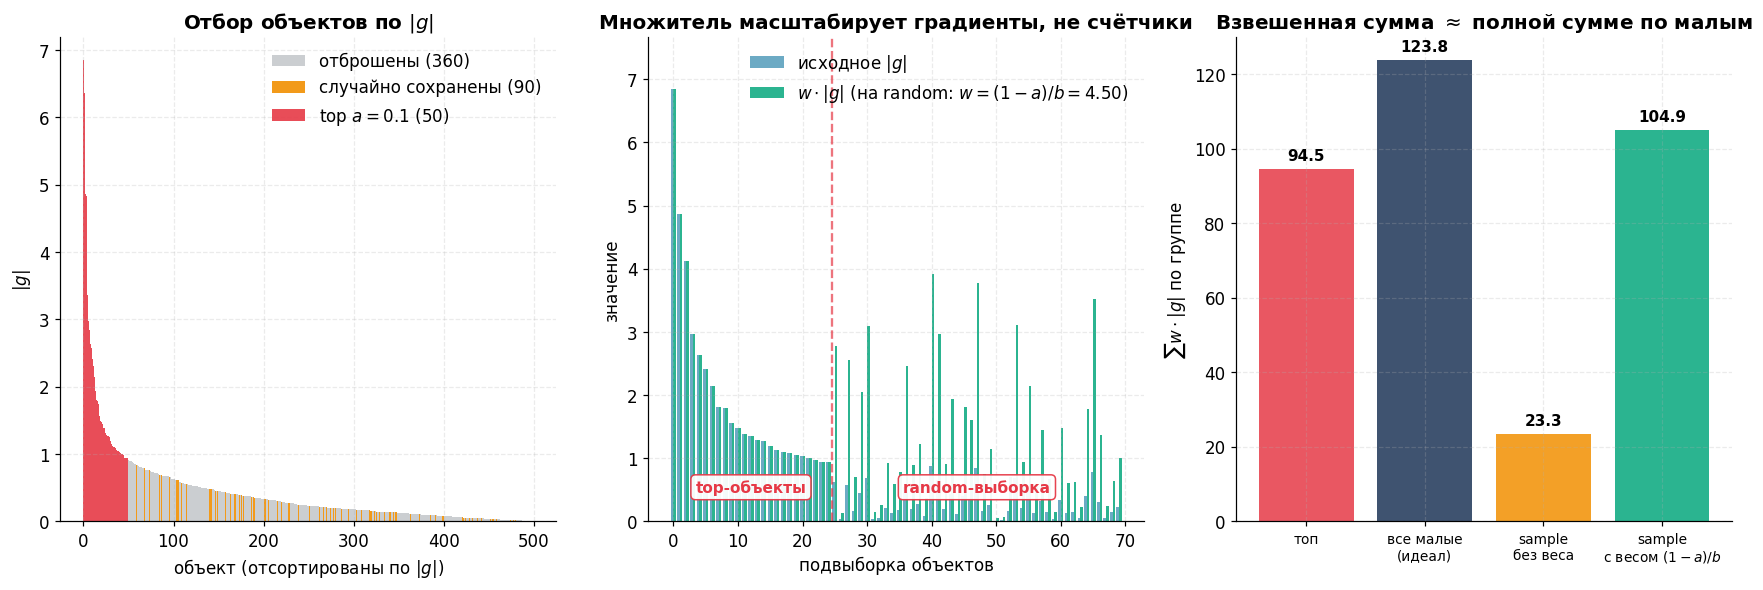

Параметры: a = 0.1, b = 0.2,  fact = (1-a)/b = 4.50
Сумма по всем малым (идеал):                123.81
Сумма по random-sample БЕЗ веса:            23.31   (заниженная)
Сумма по random-sample С весом (1-a)/b:     104.90   (≈ полной)


In [ ]:
# Демонстрация GOSS: множитель применяется к ГРАДИЕНТАМ, не к счётчикам
np.random.seed(7)
n = 500
abs_g = np.concatenate([np.random.exponential(0.3, n - 60),
                        np.random.exponential(1.5, 60)])
abs_g = np.sort(abs_g)[::-1]

a_top, b_rand = 0.1, 0.2
top_n  = int(a_top * n)
rand_n = int(b_rand * (n - top_n))
fact = (1 - a_top) / b_rand

top_idx     = np.arange(top_n)
rest_idx    = np.arange(top_n, n)
rand_idx    = np.random.choice(rest_idx, size=rand_n, replace=False)
dropped_idx = np.setdiff1d(rest_idx, rand_idx)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# ===== 1. Распределение |g| с тремя зонами =====
ax = axes[0]
xs = np.arange(n)
ax.bar(xs[dropped_idx], abs_g[dropped_idx], color=PALETTE['gray'],   alpha=0.35,
       width=1.0, label=f'отброшены ({len(dropped_idx)})')
ax.bar(xs[rand_idx],    abs_g[rand_idx],    color=PALETTE['orange'], alpha=0.9,
       width=1.0, label=f'случайно сохранены ({rand_n})')
ax.bar(xs[top_idx],     abs_g[top_idx],     color=PALETTE['red'],    alpha=0.9,
       width=1.0, label=fr'top $a = {a_top}$ ({top_n})')
ax.set_title(r'Отбор объектов по $|g|$')
ax.set_xlabel(r'объект (отсортированы по $|g|$)')
ax.set_ylabel(r'$|g|$')
ax.legend(loc='upper right', framealpha=0.95)

# ===== 2. Исходные |g| vs взвешенные w·|g| =====
ax = axes[1]
showing = np.concatenate([top_idx[::2], rand_idx[::2]])
w = np.ones(n)
w[rand_idx] *= fact
top_count = len(top_idx[::2])

orig_show     = abs_g[showing]
weighted_show = w[showing] * abs_g[showing]
xs_show       = np.arange(len(showing))

ax.bar(xs_show - 0.2, orig_show,     width=0.4,
       color=PALETTE['blue'],  alpha=0.7,  label=r'исходное $|g|$')
ax.bar(xs_show + 0.2, weighted_show, width=0.4,
       color=PALETTE['green'], alpha=0.85,
       label=fr'$w \cdot |g|$ (на random: $w = (1-a)/b = {fact:.2f}$)')

# граница top/random со ВЛОЖЕННЫМИ подписями ВНИЗУ графика —
# не пересекаются с легендой в верхнем-правом
ax.axvline(top_count - 0.5, color=PALETTE['red'], ls='--', alpha=0.7, lw=1.5)
ymax = max(weighted_show.max(), orig_show.max()) * 1.12
ax.set_ylim(0, ymax)
zone_y = ymax * 0.06
zone_kw = dict(color=PALETTE['red'], fontsize=10, fontweight='bold', ha='center',
               bbox=dict(facecolor='white', edgecolor=PALETTE['red'],
                         boxstyle='round,pad=0.3', alpha=0.95))
ax.text((top_count - 1) / 2,                       zone_y, 'top-объекты',    **zone_kw)
ax.text((top_count + len(xs_show) - 1) / 2,        zone_y, 'random-выборка', **zone_kw)

ax.set_title('Множитель масштабирует градиенты, не счётчики')
ax.set_xlabel('подвыборка объектов')
ax.set_ylabel('значение')
ax.legend(loc='upper right', framealpha=0.95)

# ===== 3. Суммарный вклад: сохраняется ли он? =====
ax = axes[2]
sum_top_full        = abs_g[top_idx].sum()
sum_small_full_data = abs_g[rest_idx].sum()
sum_rand_unweighted = abs_g[rand_idx].sum()
sum_rand_weighted   = (w[rand_idx] * abs_g[rand_idx]).sum()

# короткие двухстрочные подписи, чтобы не наезжали друг на друга
labels = ['топ',
          'все малые\n(идеал)',
          'sample\nбез веса',
          'sample\nс весом $(1-a)/b$']
values = [sum_top_full, sum_small_full_data, sum_rand_unweighted, sum_rand_weighted]
colors = [PALETTE['red'], PALETTE['dark'], PALETTE['orange'], PALETTE['green']]

bars = ax.bar(labels, values, color=colors, alpha=0.85)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + max(values) * 0.02,
            f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel(r'$\sum w \cdot |g|$ по группе')
ax.set_title(r'Взвешенная сумма $\approx$ полной сумме по малым')
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.show()

print(f'Параметры: a = {a_top}, b = {b_rand},  fact = (1-a)/b = {fact:.2f}')
print(f'Сумма по всем малым (идеал):                {sum_small_full_data:.2f}')
print(f'Сумма по random-sample БЕЗ веса:            {sum_rand_unweighted:.2f}   (заниженная)')
print(f'Сумма по random-sample С весом (1-a)/b:     {sum_rand_weighted:.2f}   (≈ полной)')

На третьем графике видно главное: **с весом $(1-a)/b$ сумма $\sum w_i |g_i|$ по случайной подвыборке приближается к сумме по всем малым объектам**. Без веса random-sample её сильно недооценивает, и gain в дереве оказался бы заниженным. Именно так множитель «компенсирует» отброшенные данные.

### §3.2 Exclusive Feature Bundling

В разрежённом пространстве признаков многие признаки **взаимоисключающие**: пара признаков редко принимает ненулевые значения одновременно. Достаточно вспомнить one-hot encoding: после него мы получаем разрежённое пространство, где почти никакие пары внутри одной OHE-группы не принимают единицу вместе.

Авторы EFB решают **задачу раскраски графа**:

* **Вершины** = признаки.
* **Рёбра** между признаками, **которые НЕ взаимоисключающие** (то есть хотя бы на одном объекте одновременно ненулевые).
* **Цвет** = бандл признаков. Признаки одного цвета склеиваются в один новый.

Важная тонкость, на которой легко ошибиться: рёбра рисуем между **конфликтующими** парами (которые НЕЛЬЗЯ объединять). Чем граф разрежённее, тем меньше цветов нужно.

**Пример: две категориальные переменные после OHE.** Пусть исходно есть две категории, каждая с тремя значениями. После OHE получаем 6 бинарных признаков: $f_1, f_2, f_3$ из первой категории и $f_4, f_5, f_6$ из второй.

* Внутри одной OHE-группы признаки **взаимоисключающие** (только одна из $f_1, f_2, f_3$ равна 1 на каждом объекте), поэтому рёбер между ними **нет**.
* Между группами признаки **могут одновременно быть ненулевыми** ($f_1=1, f_4=1$ это валидная комбинация), поэтому есть рёбра $f_i - f_j$ для $i \in \{1,2,3\}, j \in \{4,5,6\}$.

Итог: граф двудольный с 9 рёбрами, раскрашивается в **2 цвета**, бандлы получаются $\{f_1, f_2, f_3\}$ и $\{f_4, f_5, f_6\}$. То есть из 6 признаков мы получаем 2 склеенных.

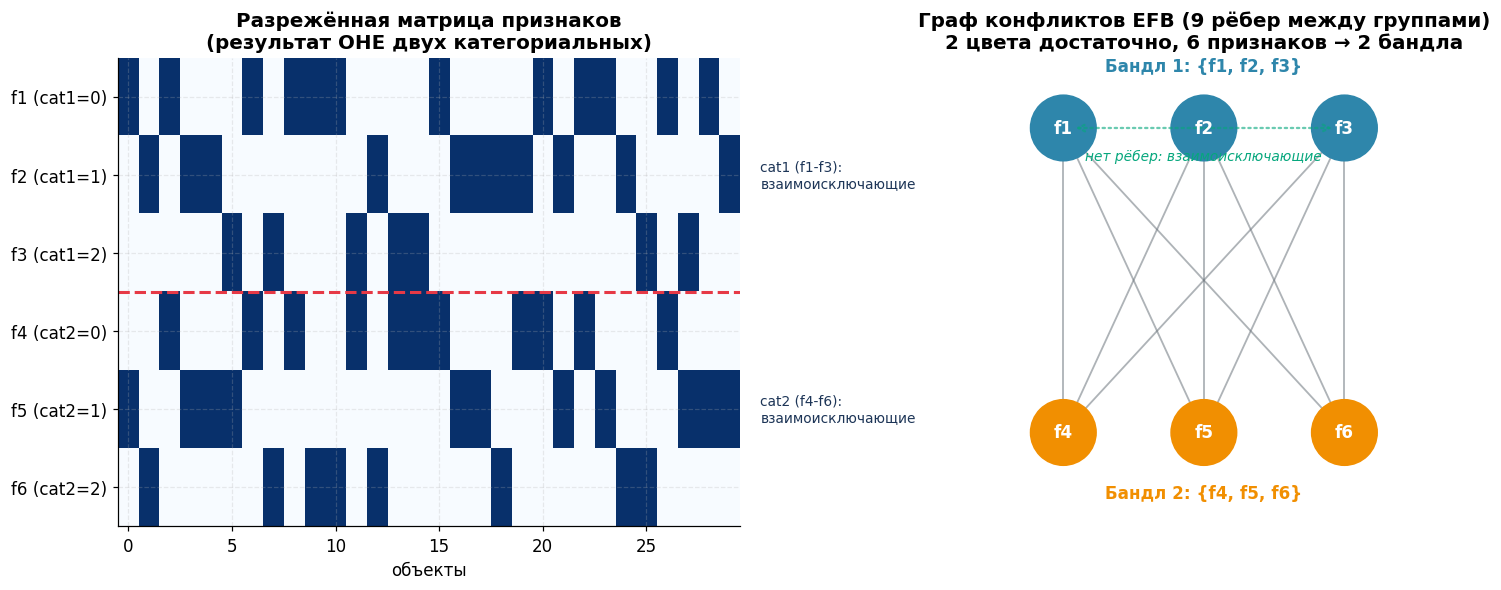

In [ ]:
# EFB: правильный граф и раскраска
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Левая панель: матрица признаков
np.random.seed(0)
n_objs = 30
cat1 = np.random.choice(3, n_objs)
cat2 = np.random.choice(3, n_objs)

F = np.zeros((n_objs, 6))
for i in range(n_objs):
    F[i, cat1[i]] = 1
    F[i, 3 + cat2[i]] = 1

ax = axes[0]
ax.imshow(F.T, aspect='auto', cmap='Blues')
ax.set_yticks(range(6))
ax.set_yticklabels(['f1 (cat1=0)', 'f2 (cat1=1)', 'f3 (cat1=2)',
                    'f4 (cat2=0)', 'f5 (cat2=1)', 'f6 (cat2=2)'])
ax.set_xlabel('объекты')
ax.set_title('Разрежённая матрица признаков\n(результат OHE двух категориальных)')
# подсветка границы между группами
ax.axhline(2.5, color=PALETTE['red'], lw=2, ls='--')
ax.text(n_objs + 0.5, 1, 'cat1 (f1-f3):\nвзаимоисключающие',
        fontsize=9, va='center', color=PALETTE['dark'])
ax.text(n_objs + 0.5, 4, 'cat2 (f4-f6):\nвзаимоисключающие',
        fontsize=9, va='center', color=PALETTE['dark'])

# Правая панель: ПРАВИЛЬНЫЙ граф конфликтов
ax = axes[1]
positions = {
    'f1': (0.2, 0.85), 'f2': (0.5, 0.85), 'f3': (0.8, 0.85),
    'f4': (0.2, 0.20), 'f5': (0.5, 0.20), 'f6': (0.8, 0.20),
}
# Рёбра ТОЛЬКО между группами (cat1 vs cat2)
edges_conflict = [(a, b) for a in ['f1','f2','f3'] for b in ['f4','f5','f6']]
colors_node = {'f1': PALETTE['blue'], 'f2': PALETTE['blue'], 'f3': PALETTE['blue'],
               'f4': PALETTE['orange'], 'f5': PALETTE['orange'], 'f6': PALETTE['orange']}

for (a, b) in edges_conflict:
    ax.plot([positions[a][0], positions[b][0]],
            [positions[a][1], positions[b][1]],
            color=PALETTE['gray'], lw=1.2, alpha=0.55, zorder=1)

for name, (x, y) in positions.items():
    ax.add_patch(Circle((x, y), 0.07, color=colors_node[name], zorder=3))
    ax.text(x, y, name, ha='center', va='center', color='white',
            fontweight='bold', fontsize=11, zorder=4)

# Подписи бандлов
ax.text(0.5, 0.97, 'Бандл 1: {f1, f2, f3}', ha='center',
        fontsize=11, fontweight='bold', color=PALETTE['blue'])
ax.text(0.5, 0.06, 'Бандл 2: {f4, f5, f6}', ha='center',
        fontsize=11, fontweight='bold', color=PALETTE['orange'])

# Поясняющая стрелка: внутри группы рёбер нет
ax.annotate('', xy=(0.78, 0.85), xytext=(0.22, 0.85),
            arrowprops=dict(arrowstyle='<->', color=PALETTE['green'],
                            lw=1.5, ls=':', alpha=0.6))
ax.text(0.5, 0.78, 'нет рёбер: взаимоисключающие',
        ha='center', fontsize=9, color=PALETTE['green'], style='italic')

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Граф конфликтов EFB (9 рёбер между группами)\n2 цвета достаточно, 6 признаков → 2 бандла')

plt.tight_layout()
plt.show()

После раскраски все признаки одного цвета склеиваются в один. Технически это делается через смещения по диапазонам значений: чтобы значения из разных склеенных признаков не путались, к каждому добавляется отдельный «оффсет». Итог: меньше признаков для перебора в каждой вершине, тот же gain.

### §3.3 Правило роста дерева в LightGBM

Обычные деревья растут **level-wise** (по уровням): берём все вершины текущего уровня и одновременно разбиваем их. Ограничение тут естественное, это максимальная глубина. Порядок появления вершин примерно такой: сначала корень, потом оба ребёнка корня, потом все 4 внука, потом 8 правнуков и т.д.

В LightGBM же новые узлы выбираются на основе **максимизации текущей информативности** в модели. Из всех возможных листов в дереве в приоритете будет создана та вершина, чьё разбиение даёт больший прирост в gain на этом шаге. Получается другой порядок и сильно несбалансированные деревья. Зато это **логичнее связано с исходной целью минимизации функции потерь**: каждый шаг даёт максимально возможное снижение лосса.

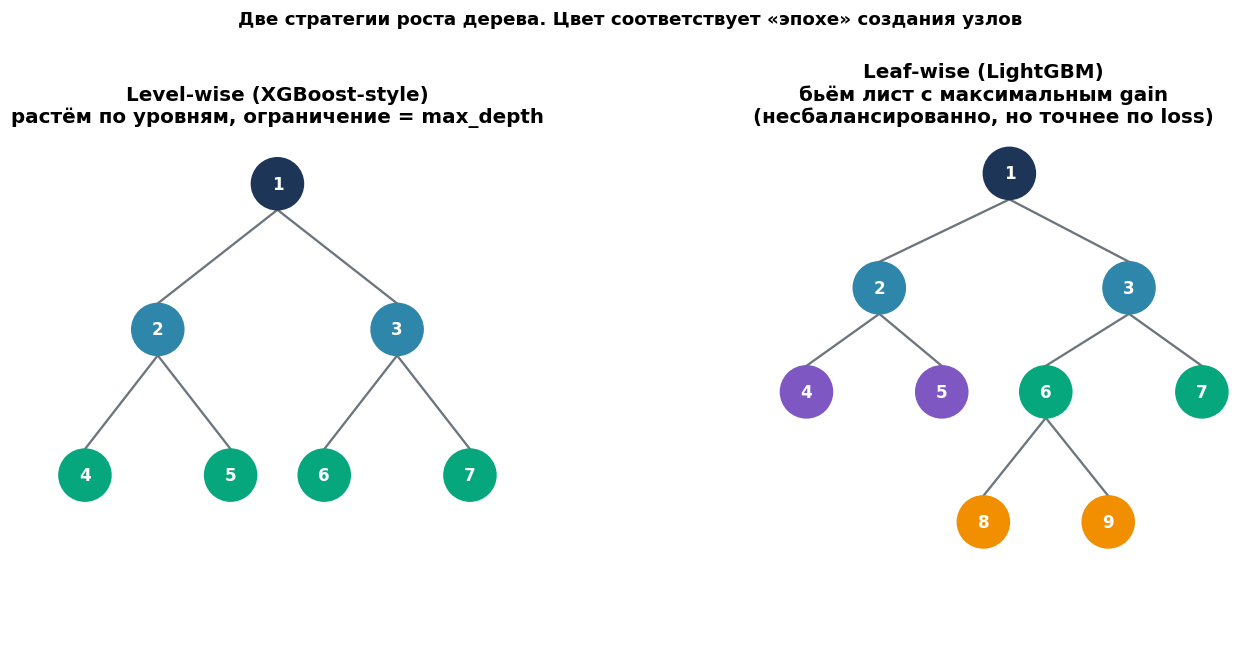

In [ ]:
# Level-wise vs leaf-wise с корректной бинарной структурой
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

def draw_tree(ax, positions, edges, order_color, title):
    for (a, b) in edges:
        ax.plot([positions[a][0], positions[b][0]],
                [positions[a][1] - 0.05, positions[b][1] + 0.05],
                color=PALETTE['gray'], lw=1.5)
    for n, (x, y) in positions.items():
        ax.add_patch(Circle((x, y), 0.05, color=order_color[n], zorder=3))
        ax.text(x, y, str(n), ha='center', va='center', color='white',
                fontweight='bold', fontsize=11, zorder=4)
    ax.set_title(title)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal'); ax.axis('off')

# Level-wise: симметричное дерево глубины 3, 7 узлов, в порядке появления
ax = axes[0]
lvl_pos = {
    1: (0.5, 0.9),
    2: (0.27, 0.62), 3: (0.73, 0.62),
    4: (0.13, 0.34), 5: (0.41, 0.34), 6: (0.59, 0.34), 7: (0.87, 0.34),
}
lvl_edges = [(1,2),(1,3),(2,4),(2,5),(3,6),(3,7)]
lvl_colors = {1: PALETTE['dark'],
              2: PALETTE['blue'], 3: PALETTE['blue'],
              4: PALETTE['green'], 5: PALETTE['green'],
              6: PALETTE['green'], 7: PALETTE['green']}
draw_tree(ax, lvl_pos, lvl_edges, lvl_colors,
          'Level-wise (XGBoost-style)\nрастём по уровням, ограничение = max_depth')

# Leaf-wise: тот же набор сплитов, но в порядке наибольшего gain
# Структурно: 1 root → дети 2, 3. Затем самый "выгодный" лист, 2, снова бьётся:
# 2 → дети 4, 5. Потом лист 3 бьётся: 3 → дети 6, 7. Потом лист 6 бьётся: 6 → дети 8, 9.
# Это даёт корректное бинарное дерево с 9 узлами.
ax = axes[1]
lf_pos = {
    1: (0.55, 0.92),
    2: (0.30, 0.70), 3: (0.78, 0.70),
    4: (0.16, 0.50), 5: (0.42, 0.50),
    6: (0.62, 0.50), 7: (0.92, 0.50),
    8: (0.50, 0.25), 9: (0.74, 0.25),
}
lf_edges = [(1,2),(1,3),(2,4),(2,5),(3,6),(3,7),(6,8),(6,9)]
# Цвета по очерёдности появления при leaf-wise
# split 1: создаёт 2,3 (раньше всех)
# split 2: лист 2 был лучший, создаёт 4,5
# split 3: лист 3 был следующий, создаёт 6,7
# split 4: лист 6 был лучший, создаёт 8,9
lf_colors = {1: PALETTE['dark'],
             2: PALETTE['blue'],   3: PALETTE['blue'],
             4: PALETTE['purple'], 5: PALETTE['purple'],
             6: PALETTE['green'],  7: PALETTE['green'],
             8: PALETTE['orange'], 9: PALETTE['orange']}
draw_tree(ax, lf_pos, lf_edges, lf_colors,
          'Leaf-wise (LightGBM)\nбьём лист с максимальным gain\n(несбалансированно, но точнее по loss)')

plt.suptitle('Две стратегии роста дерева. Цвет соответствует «эпохе» создания узлов',
             fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

На правом графике структура **валидная бинарная**: после четырёх сплитов получаем 5 листьев и 4 внутренних узла, 9 узлов всего. В leaf-wise каждый сплит создаёт два потомка, и сплитаются те листья, разбиение которых сейчас даёт максимальный прирост gain. Видно, как левая ветвь развита глубже правой, потому что её листья были выгоднее для разбиения.

## §4. CatBoost

CatBoost тоже хорошая базовая библиотека для обучения решающих деревьев со своими подходами. Кратко обозначим два главных и подробнее посмотрим на третий:

* **Упорядоченный градиентный бустинг (ordered boosting).** В обычном бустинге градиенты для $i$-го объекта считаются по модели, которая обучалась в том числе на этом объекте, что приводит к смещению (target leakage). CatBoost для каждого объекта использует только подмножество данных, идущее перед ним в случайно выбранной перестановке, и так получает «честные» градиенты.
* **Целевая обработка категориальных признаков.** Вместо OHE для категории строятся счётчики «среднего таргета», но считаются они опять по предыдущим объектам в перестановке. Это даёт компактное и устойчивое к утечке кодирование.
* **Oblivious decision trees.** Дальше подробнее.

### §4.1 Oblivious Decision Trees

Основное изменение в построении дерева: на **каждом уровне разбиения от корневой вершины используется одно и то же правило**. Фактически это означает, что на глубине $h$ все вершины разбиваются по пороговому значению одного и того же признака.

В результате получаем сбалансированное дерево глубины $H$, где каждый уровень $h$ связан со своим правилом $f_h(x)$. Пространство признаков разбивается ровно на $2^H$ ячеек, а сам классификатор задаётся таблицей решений:

$$
a(x) = T\bigl(f_1(x), \dots, f_H(x)\bigr).
$$

В семинаре приводится пример с задачей $H=2$, в которой таблица $T$ задаёт зависимость, эквивалентную «логическому равенству» (XNOR): $T(0,0) = T(1,1) = 1$, а $T(0,1) = T(1,0) = 0$. Заметим, что в семинаре это называется задачей XOR, хотя математически таблица соответствует именно XNOR. Чистый XOR это инверсия: $T(0,0) = T(1,1) = 0$, $T(0,1) = T(1,0) = 1$.

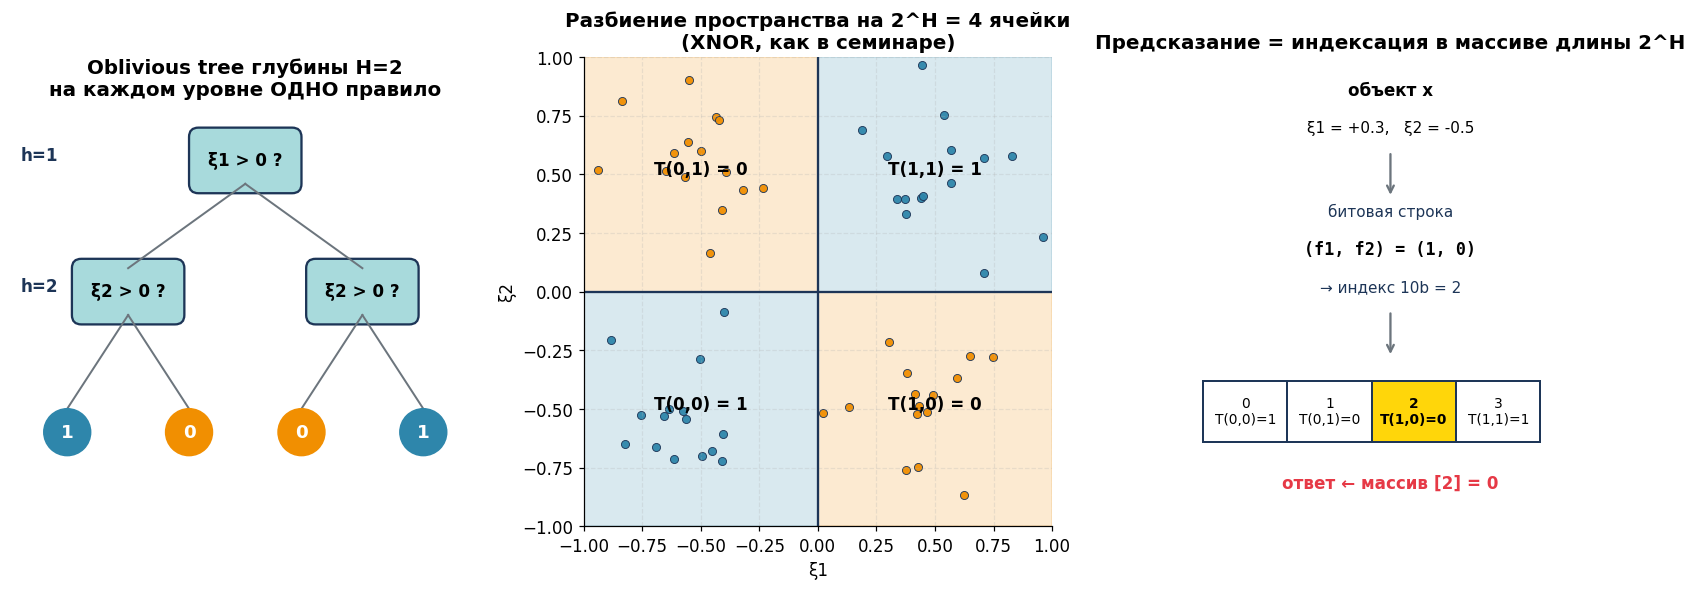

In [ ]:
# Oblivious tree на примере XNOR (как в семинаре)
fig = plt.figure(figsize=(15, 5.5))

# ============ Левая панель: само oblivious дерево ============
ax1 = plt.subplot(1, 3, 1)

# Уровень h=1: одно правило ξ1 > 0
ax1.add_patch(FancyBboxPatch((0.4, 0.78), 0.2, 0.1,
              boxstyle='round,pad=0.02', fc=PALETTE['light'], ec=PALETTE['dark'], lw=1.5))
ax1.text(0.5, 0.83, 'ξ1 > 0 ?', ha='center', va='center', fontweight='bold', fontsize=11)

# Уровень h=2: на обеих вершинах одно и то же правило ξ2 > 0
for cx in [0.25, 0.75]:
    ax1.add_patch(FancyBboxPatch((cx-0.1, 0.5), 0.2, 0.1,
                  boxstyle='round,pad=0.02', fc=PALETTE['light'], ec=PALETTE['dark'], lw=1.5))
    ax1.text(cx, 0.55, 'ξ2 > 0 ?', ha='center', va='center', fontweight='bold', fontsize=11)

# Листы для XNOR: T(0,0)=1, T(0,1)=0, T(1,0)=0, T(1,1)=1
# Порядок листьев слева направо: f1=0,f2=0 | f1=0,f2=1 | f1=1,f2=0 | f1=1,f2=1
leaf_data = [(0.12, 1), (0.38, 0), (0.62, 0), (0.88, 1)]
for x, val in leaf_data:
    c = PALETTE['blue'] if val == 1 else PALETTE['orange']
    ax1.add_patch(Circle((x, 0.25), 0.05, color=c, zorder=3))
    ax1.text(x, 0.25, str(val), ha='center', va='center', color='white',
             fontweight='bold', fontsize=12, zorder=4)

# Соединения
def lin(ax, x1, y1, x2, y2):
    ax.plot([x1, x2], [y1, y2], color=PALETTE['gray'], lw=1.3)
lin(ax1, 0.5, 0.78, 0.25, 0.6); lin(ax1, 0.5, 0.78, 0.75, 0.6)
lin(ax1, 0.25, 0.5, 0.12, 0.3); lin(ax1, 0.25, 0.5, 0.38, 0.3)
lin(ax1, 0.75, 0.5, 0.62, 0.3); lin(ax1, 0.75, 0.5, 0.88, 0.3)

ax1.text(0.02, 0.83, 'h=1', fontsize=11, fontweight='bold', color=PALETTE['dark'])
ax1.text(0.02, 0.55, 'h=2', fontsize=11, fontweight='bold', color=PALETTE['dark'])
ax1.set_xlim(0, 1); ax1.set_ylim(0.15, 0.95); ax1.set_aspect('equal'); ax1.axis('off')
ax1.set_title('Oblivious tree глубины H=2\nна каждом уровне ОДНО правило')

# ============ Средняя панель: ячейки в пространстве признаков ============
ax2 = plt.subplot(1, 3, 2)

# Согласуем цвета фона с цветами листьев:
#   класс 1 (XNOR=1), голубой,    класс 0 (XNOR=0), оранжевый
c1, c0 = PALETTE['blue'], PALETTE['orange']
# bottom-left  (ξ1<0, ξ2<0): T(0,0)=1
ax2.axhspan(-1, 0, xmin=0,   xmax=0.5, color=c1, alpha=0.18)
# bottom-right (ξ1>0, ξ2<0): T(1,0)=0
ax2.axhspan(-1, 0, xmin=0.5, xmax=1.0, color=c0, alpha=0.18)
# top-left     (ξ1<0, ξ2>0): T(0,1)=0
ax2.axhspan(0,  1, xmin=0,   xmax=0.5, color=c0, alpha=0.18)
# top-right    (ξ1>0, ξ2>0): T(1,1)=1
ax2.axhspan(0,  1, xmin=0.5, xmax=1.0, color=c1, alpha=0.18)

ax2.text(-0.5, -0.5, 'T(0,0) = 1', ha='center', fontsize=11, fontweight='bold')
ax2.text( 0.5, -0.5, 'T(1,0) = 0', ha='center', fontsize=11, fontweight='bold')
ax2.text(-0.5,  0.5, 'T(0,1) = 0', ha='center', fontsize=11, fontweight='bold')
ax2.text( 0.5,  0.5, 'T(1,1) = 1', ha='center', fontsize=11, fontweight='bold')

# Сгенерируем точки для каждого квадранта; цвет совпадает с фоном
np.random.seed(2)
for sgn1, sgn2, lab in [(-1,-1,1), (-1,1,0), (1,-1,0), (1,1,1)]:
    cx, cy = sgn1*0.5, sgn2*0.5
    pts = np.random.normal(0, 0.18, (15, 2)) + np.array([cx, cy])
    c = c1 if lab == 1 else c0
    ax2.scatter(pts[:,0], pts[:,1], color=c, s=28, alpha=0.95,
                edgecolor=PALETTE['dark'], linewidth=0.6)

ax2.axhline(0, color=PALETTE['dark'], lw=1.5)
ax2.axvline(0, color=PALETTE['dark'], lw=1.5)
ax2.set_xlim(-1, 1); ax2.set_ylim(-1, 1)
ax2.set_xlabel('ξ1'); ax2.set_ylabel('ξ2')
ax2.set_title('Разбиение пространства на 2^H = 4 ячейки\n(XNOR, как в семинаре)')

# ============ Правая панель: предсказание как индекс в хэш-таблице ============
ax3 = plt.subplot(1, 3, 3)
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.set_aspect('equal'); ax3.axis('off')
ax3.set_title('Предсказание = индексация в массиве длины 2^H')

# Стрелка от объекта к битовой строке к ячейке
ax3.text(0.5, 0.92, 'объект x', ha='center', fontsize=11, fontweight='bold')
ax3.text(0.5, 0.84, 'ξ1 = +0.3,   ξ2 = -0.5', ha='center', fontsize=10)

ax3.annotate('', xy=(0.5, 0.70), xytext=(0.5, 0.80),
             arrowprops=dict(arrowstyle='->', lw=1.5, color=PALETTE['gray']))
ax3.text(0.5, 0.66, 'битовая строка', ha='center', fontsize=10, color=PALETTE['dark'])
ax3.text(0.5, 0.58, '(f1, f2) = (1, 0)', ha='center', fontsize=11,
         fontweight='bold', family='monospace')
ax3.text(0.5, 0.50, '→ индекс 10b = 2', ha='center', fontsize=10, color=PALETTE['dark'])

ax3.annotate('', xy=(0.5, 0.36), xytext=(0.5, 0.46),
             arrowprops=dict(arrowstyle='->', lw=1.5, color=PALETTE['gray']))

# хэш-таблица из 4 ячеек
cell_w = 0.18
cell_h = 0.13
cell_x = np.linspace(0.1, 0.1 + 3 * cell_w, 4)
labels_cells = ['0\nT(0,0)=1', '1\nT(0,1)=0', '2\nT(1,0)=0', '3\nT(1,1)=1']
hot_cell = 2  # for index = 10b = 2
for i, (cx, lab) in enumerate(zip(cell_x, labels_cells)):
    is_hot = (i == hot_cell)
    fc = '#FFD60A' if is_hot else 'white'
    ax3.add_patch(Rectangle((cx, 0.18), cell_w, cell_h,
                             facecolor=fc, edgecolor=PALETTE['dark'], lw=1.3))
    ax3.text(cx + cell_w/2, 0.18 + cell_h/2, lab, ha='center', va='center',
             fontsize=9, fontweight='bold' if is_hot else 'normal')

ax3.text(0.5, 0.08, 'ответ ← массив [2] = 0', ha='center',
         fontsize=11, fontweight='bold', color=PALETTE['red'])

plt.tight_layout()
plt.show()

Самое полезное, что можно получить из этого подхода:

* **Сбалансированное дерево** ровно глубины $H$.
* **Чёткое разбиение пространства** на $2^H$ непересекающихся ячеек.
* **Быстрый инференс**: предсказание это просто индексация в массиве длины $2^H$, как обращение к хэш-таблице (третья панель выше). По значениям признаков объекта мы получаем битовую строку $(f_1(x), \dots, f_H(x))$, переводим её в индекс ячейки и достаём из массива готовое значение класса (для классификации) или среднее таргета (для регрессии).
* **Регуляризационный эффект**: одно правило на весь уровень не даёт переподогнаться.

Минус: каждое отдельное дерево менее выразительное, чем обычное, поэтому нужно больше деревьев. Зато каждое из них дешёвое.

## Сводная таблица

| Алгоритм   | Базовое дерево         | Поиск разбиений               | Особенность                              |
|------------|------------------------|-------------------------------|------------------------------------------|
| XGBoost    | level-wise             | exact / global / local + sparsity-aware | вторые производные, регуляризация |
| LightGBM   | leaf-wise              | histogram + GOSS              | EFB склеивает разрежённые признаки      |
| CatBoost   | oblivious (одинаковое правило на уровне) | гистограммы           | ordered boosting и счётчики для categorical |

## Список литературы

1. Tianqi Chen, Carlos Guestrin. *XGBoost: A Scalable Tree Boosting System.* https://arxiv.org/pdf/1603.02754
2. Guolin Ke et al. *LightGBM: A Highly Efficient Gradient Boosting Decision Tree.* https://papers.nips.cc/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf
3. Liudmila Prokhorenkova et al. *CatBoost: unbiased boosting with categorical features.* https://arxiv.org/pdf/1706.09516
4. Haihao Lu, Sai Praneeth Karimireddy, Natalia Ponomareva, Vahab Mirrokni. *Accelerating Gradient Boosting Machines.* AISTATS 2020.
